# Laboratorio 2. Deep Learning — Resultados finales

**Nina Nájera Marakovits**  
**Carné:** 231088  
**Curso:** CC3084 Data Science  
**Semestre:** II–2026

## Metodología

Se utilizaron únicamente los registros clasificados como Turista y Excursionista, igual que en el Laboratorio 1. Para reducir los cambios fuertes de escala se aplicó la transformación `log(1 + x)` y posteriormente una estandarización calculada únicamente con el conjunto de entrenamiento.

Los modelos se evaluaron mediante un esquema walk-forward de un mes adelante. Para predecir cada mes se utilizaron únicamente observaciones reales anteriores a ese mes; el valor que se estaba prediciendo nunca se incluyó dentro de su propia entrada.

Se construyeron dos arquitecturas:

- LSTM simple: una capa LSTM seguida de capas densas.
- LSTM apilada: dos capas LSTM con dropout, seguidas de capas densas.

Para el tuneo se reservaron los últimos 36 meses del conjunto de entrenamiento como validación. La mejor configuración se seleccionó con el menor RMSE de validación. Se probaron ventanas de 12 y 24 meses, diferentes cantidades de unidades ocultas y, en el modelo apilado, valores de dropout de 0.10 y 0.25. Todos los modelos se entrenaron durante 100 épocas con Adam y una tasa de aprendizaje de 0.003.

## Hiperparámetros seleccionados

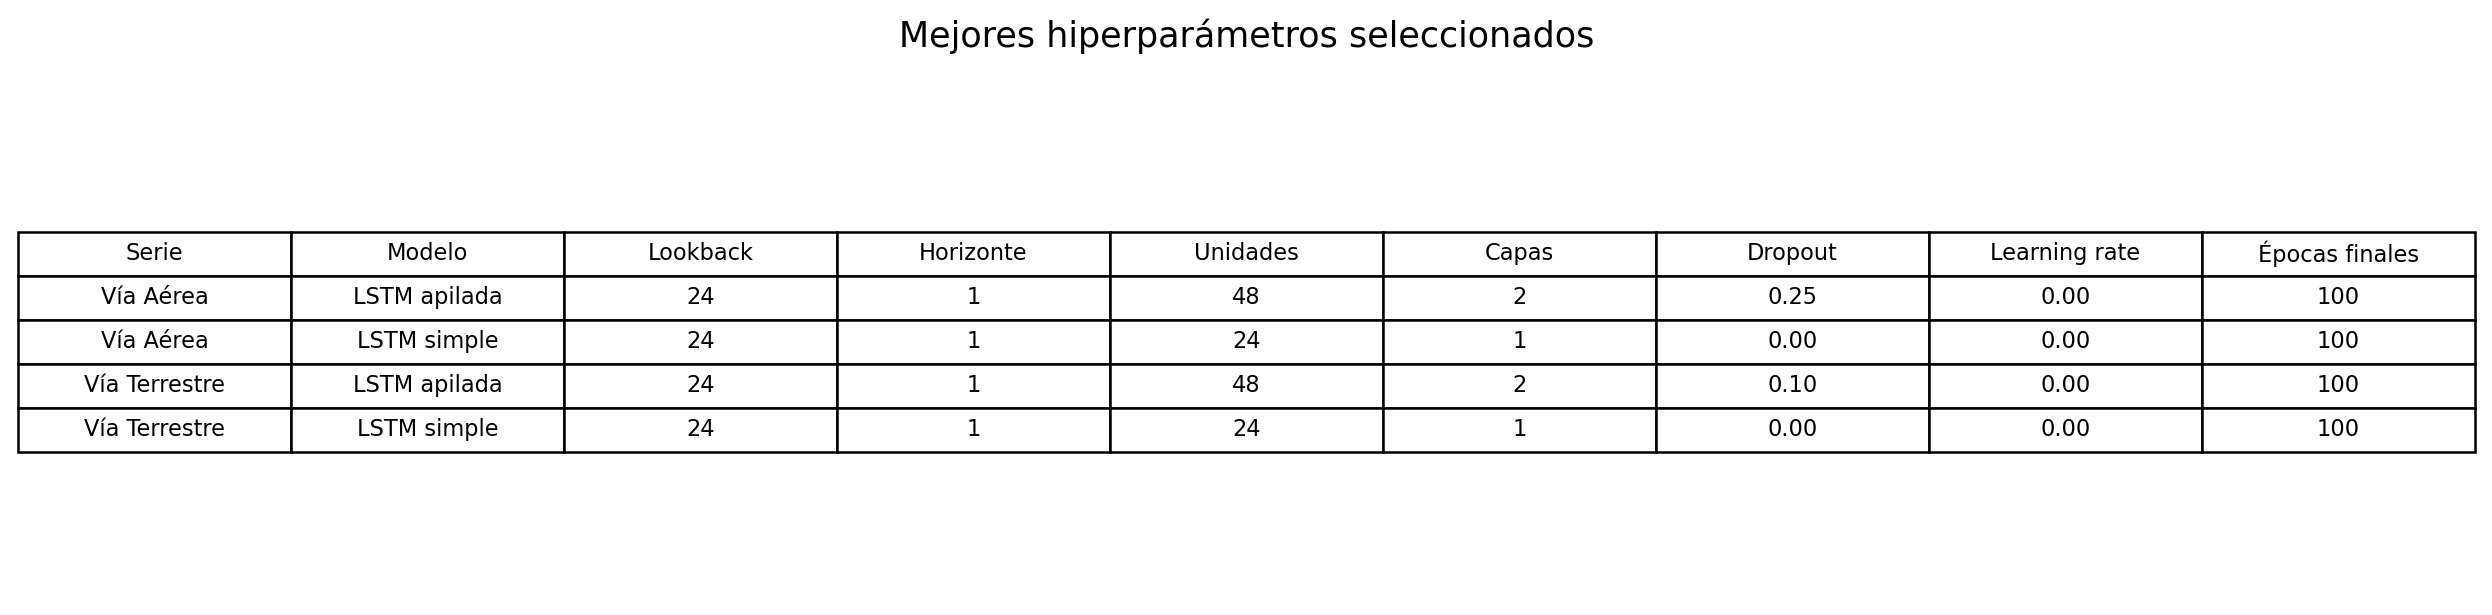

En los cuatro modelos seleccionados se eligió una ventana de 24 meses, por lo que observar dos ciclos anuales completos fue más útil que trabajar únicamente con los 12 meses anteriores. Las LSTM simples seleccionaron 24 unidades ocultas, mientras que las arquitecturas apiladas utilizaron 48 unidades y dropout.

## Resultados generales

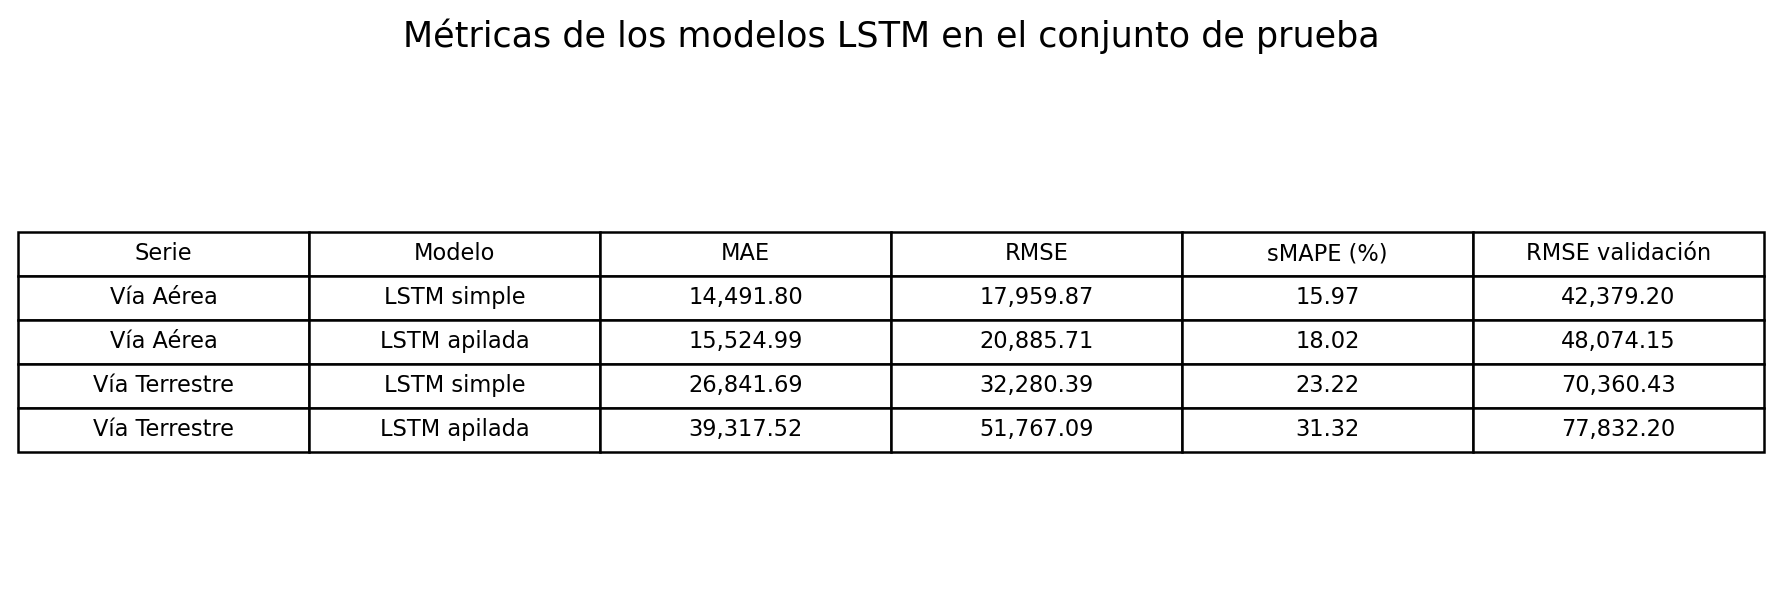

El modelo con menor error en ambas series fue la LSTM simple. La arquitectura apilada fue capaz de seguir el comportamiento general, pero presentó más errores en cambios bruscos y en algunos picos. Esto demuestra que aumentar la profundidad de la red no garantiza automáticamente una mejor predicción.

## Serie Vía Aérea — Tuneo

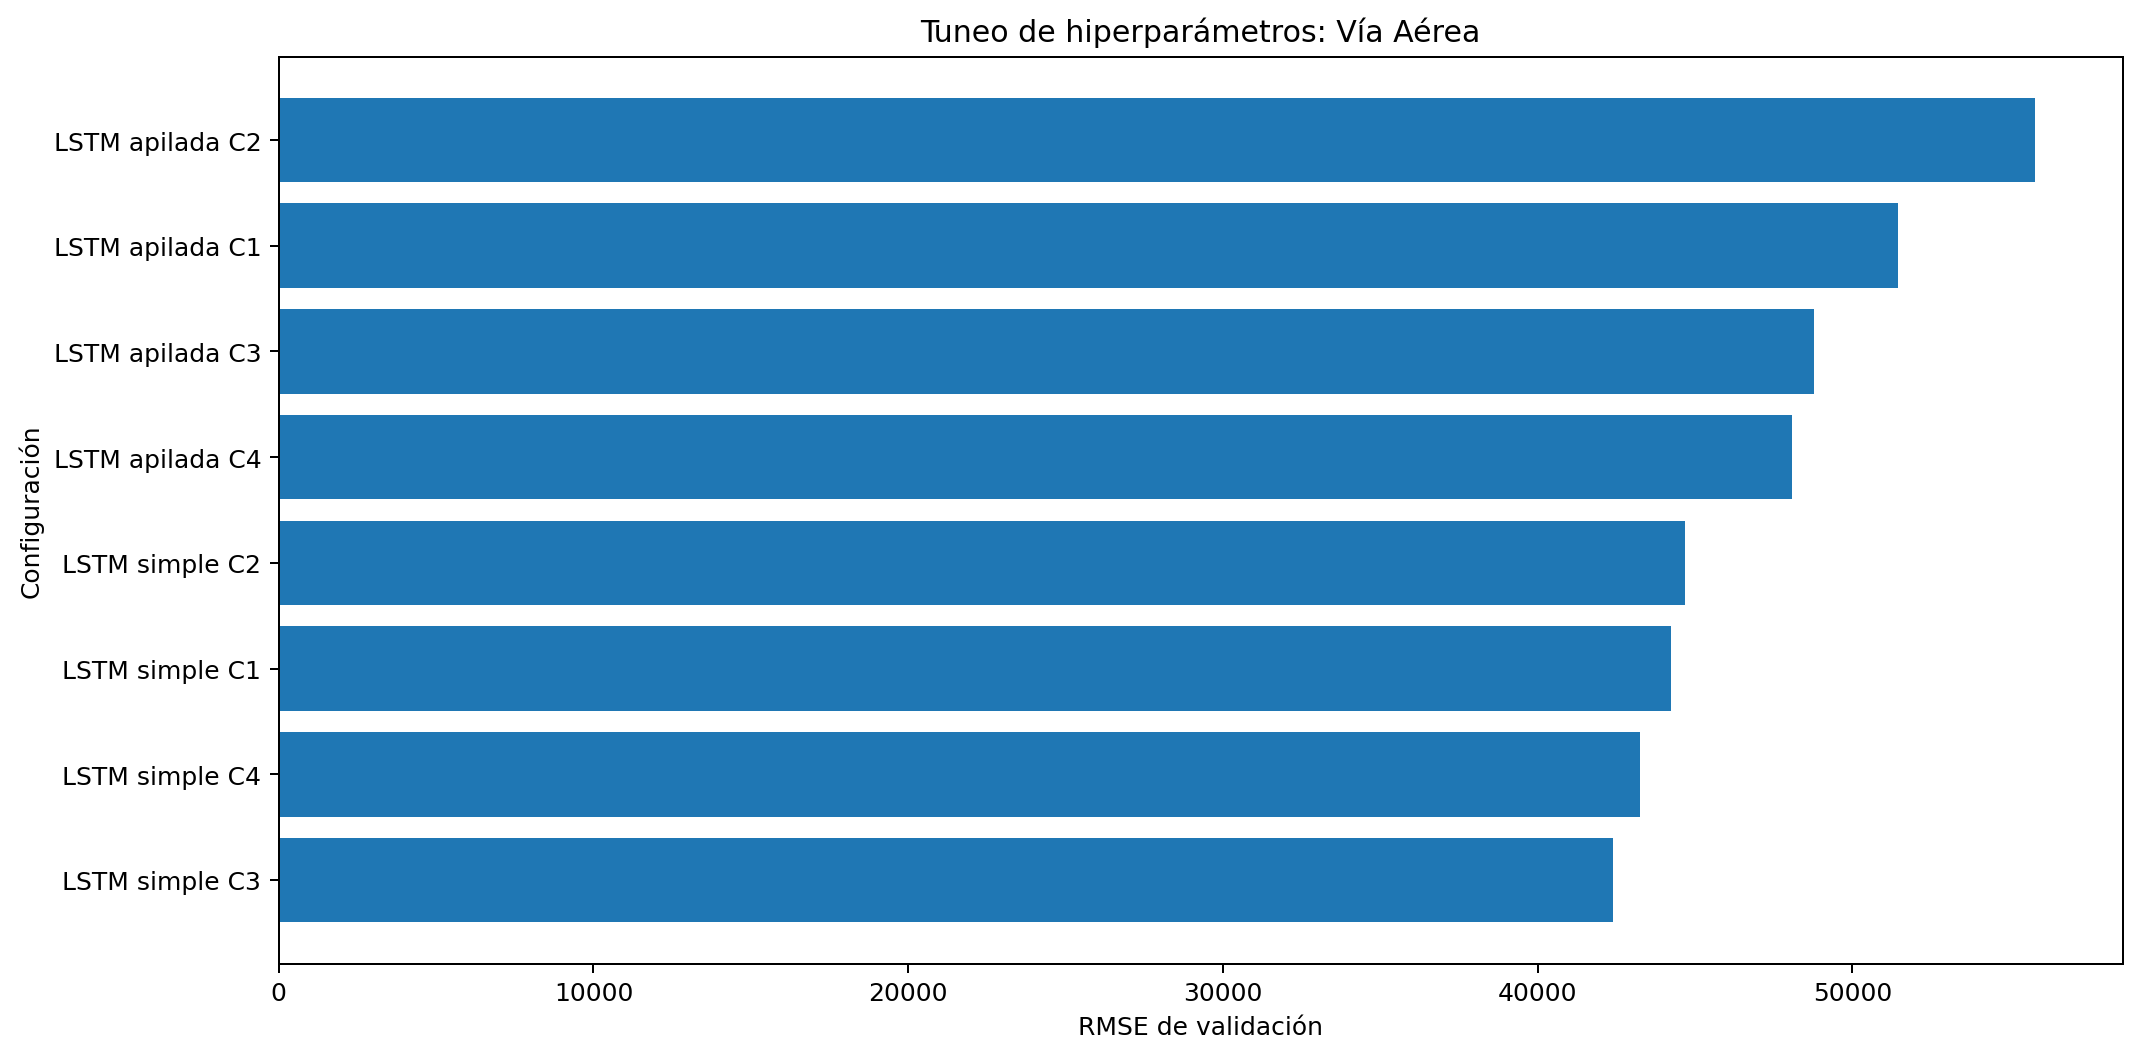

Para la serie aérea, la mejor configuración simple utilizó una ventana de 24 meses y 24 unidades ocultas. La mejor configuración apilada utilizó 24 meses, 48 unidades y dropout de 0.25. El RMSE de validación favoreció a la arquitectura simple.

## Serie Vía Aérea — Predicciones

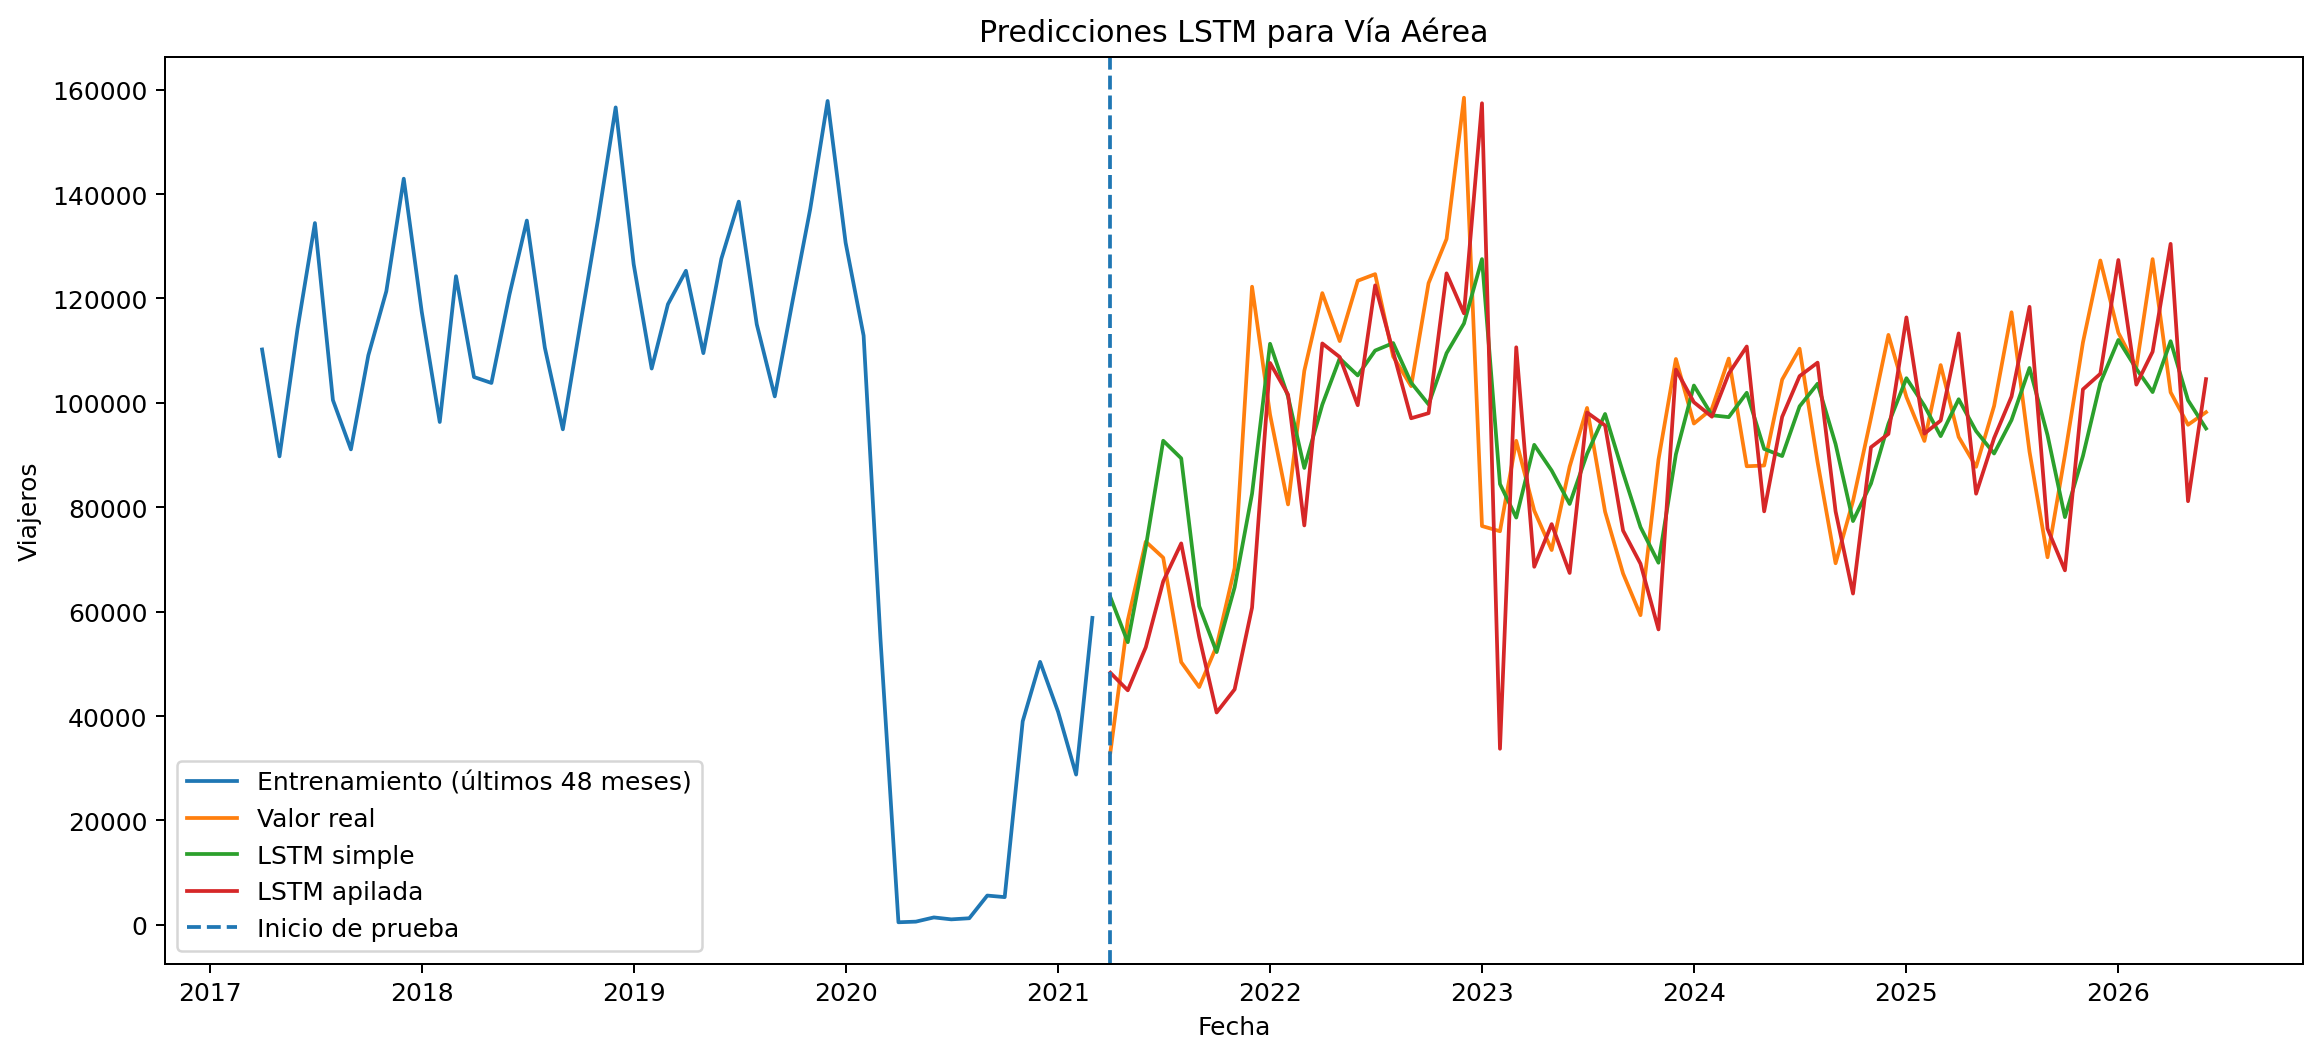

La LSTM simple obtuvo un MAE de 14,491.80 viajeros, un RMSE de 17,959.87 y un sMAPE de 15.97%. La LSTM apilada obtuvo un MAE de 15,524.99, un RMSE de 20,885.71 y un sMAPE de 18.02%.

Ambos modelos siguieron la recuperación posterior a la pandemia y reprodujeron buena parte de las fluctuaciones mensuales. La LSTM simple se mantuvo más cerca de los valores reales en la mayoría de los meses. La arquitectura apilada reaccionó con mayor intensidad a algunos cambios y produjo errores grandes cerca de ciertos picos y caídas.

### Pérdida de entrenamiento — Vía Aérea

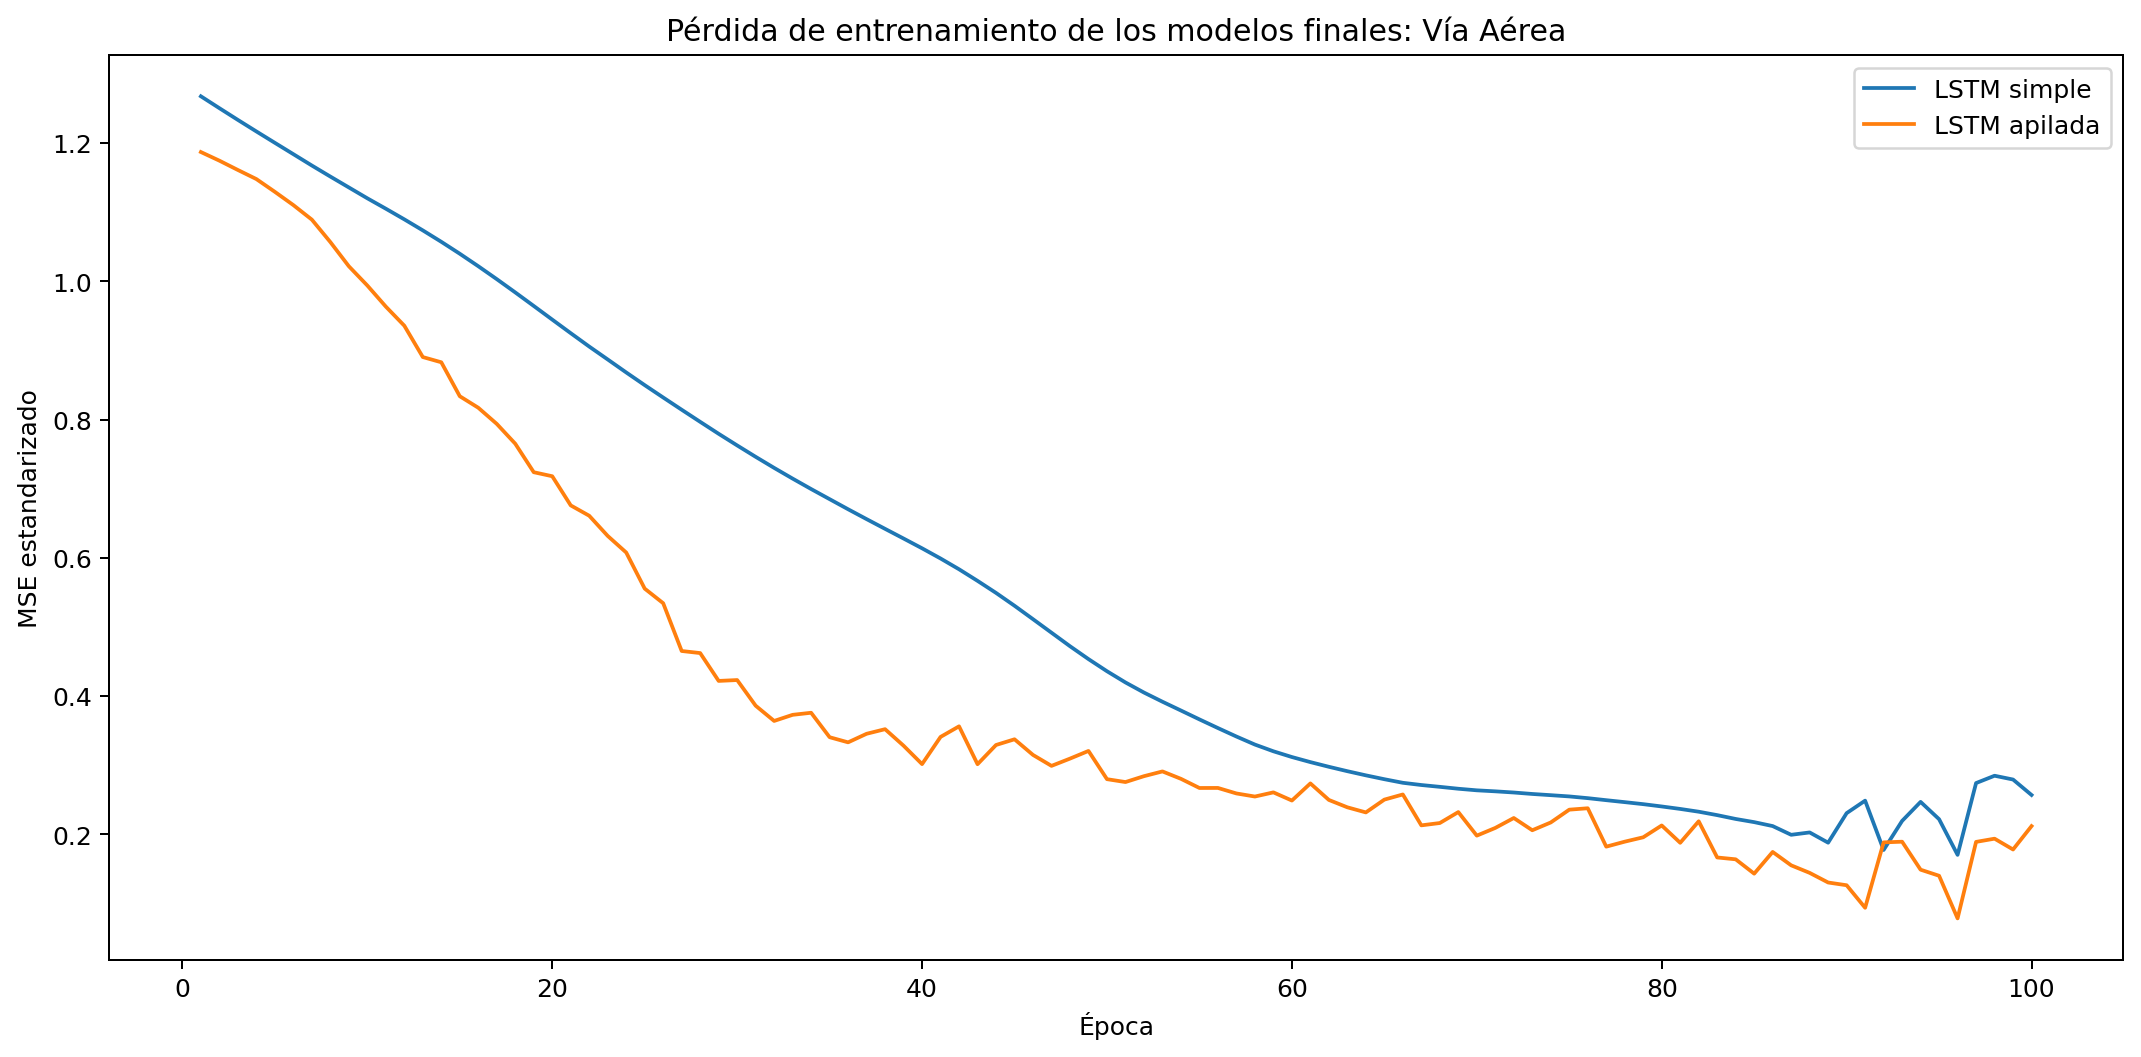

La pérdida disminuyó durante el entrenamiento de ambas arquitecturas. La LSTM simple alcanzó una pérdida final menor y un comportamiento más estable, lo cual es consistente con sus mejores métricas en el conjunto de prueba.

## Serie Vía Terrestre — Tuneo

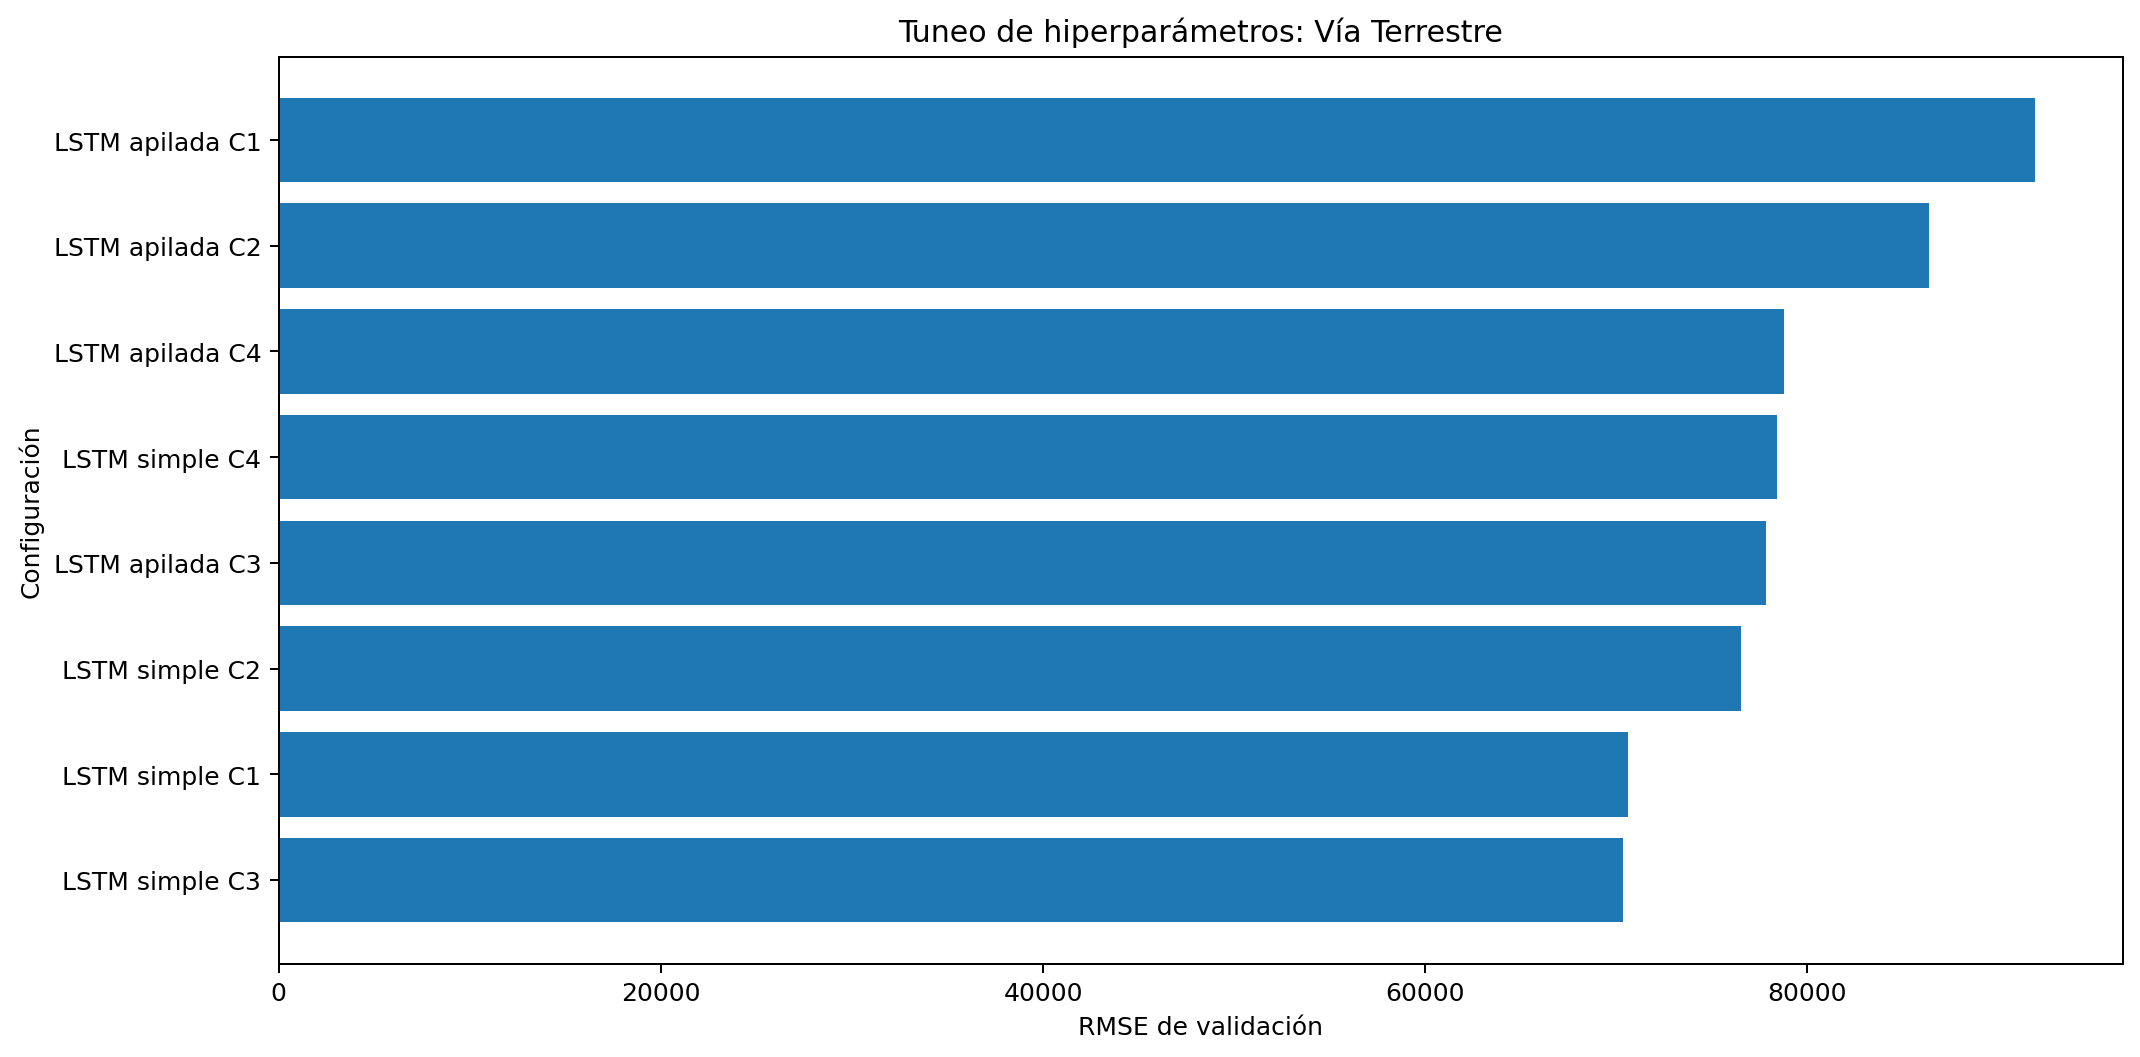

Para Vía Terrestre, la mejor LSTM simple utilizó una ventana de 24 meses y 24 unidades ocultas. La mejor LSTM apilada utilizó 24 meses, 48 unidades y dropout de 0.10. La diferencia entre sus RMSE de validación ya indicaba que la arquitectura simple era la opción más adecuada.

## Serie Vía Terrestre — Predicciones

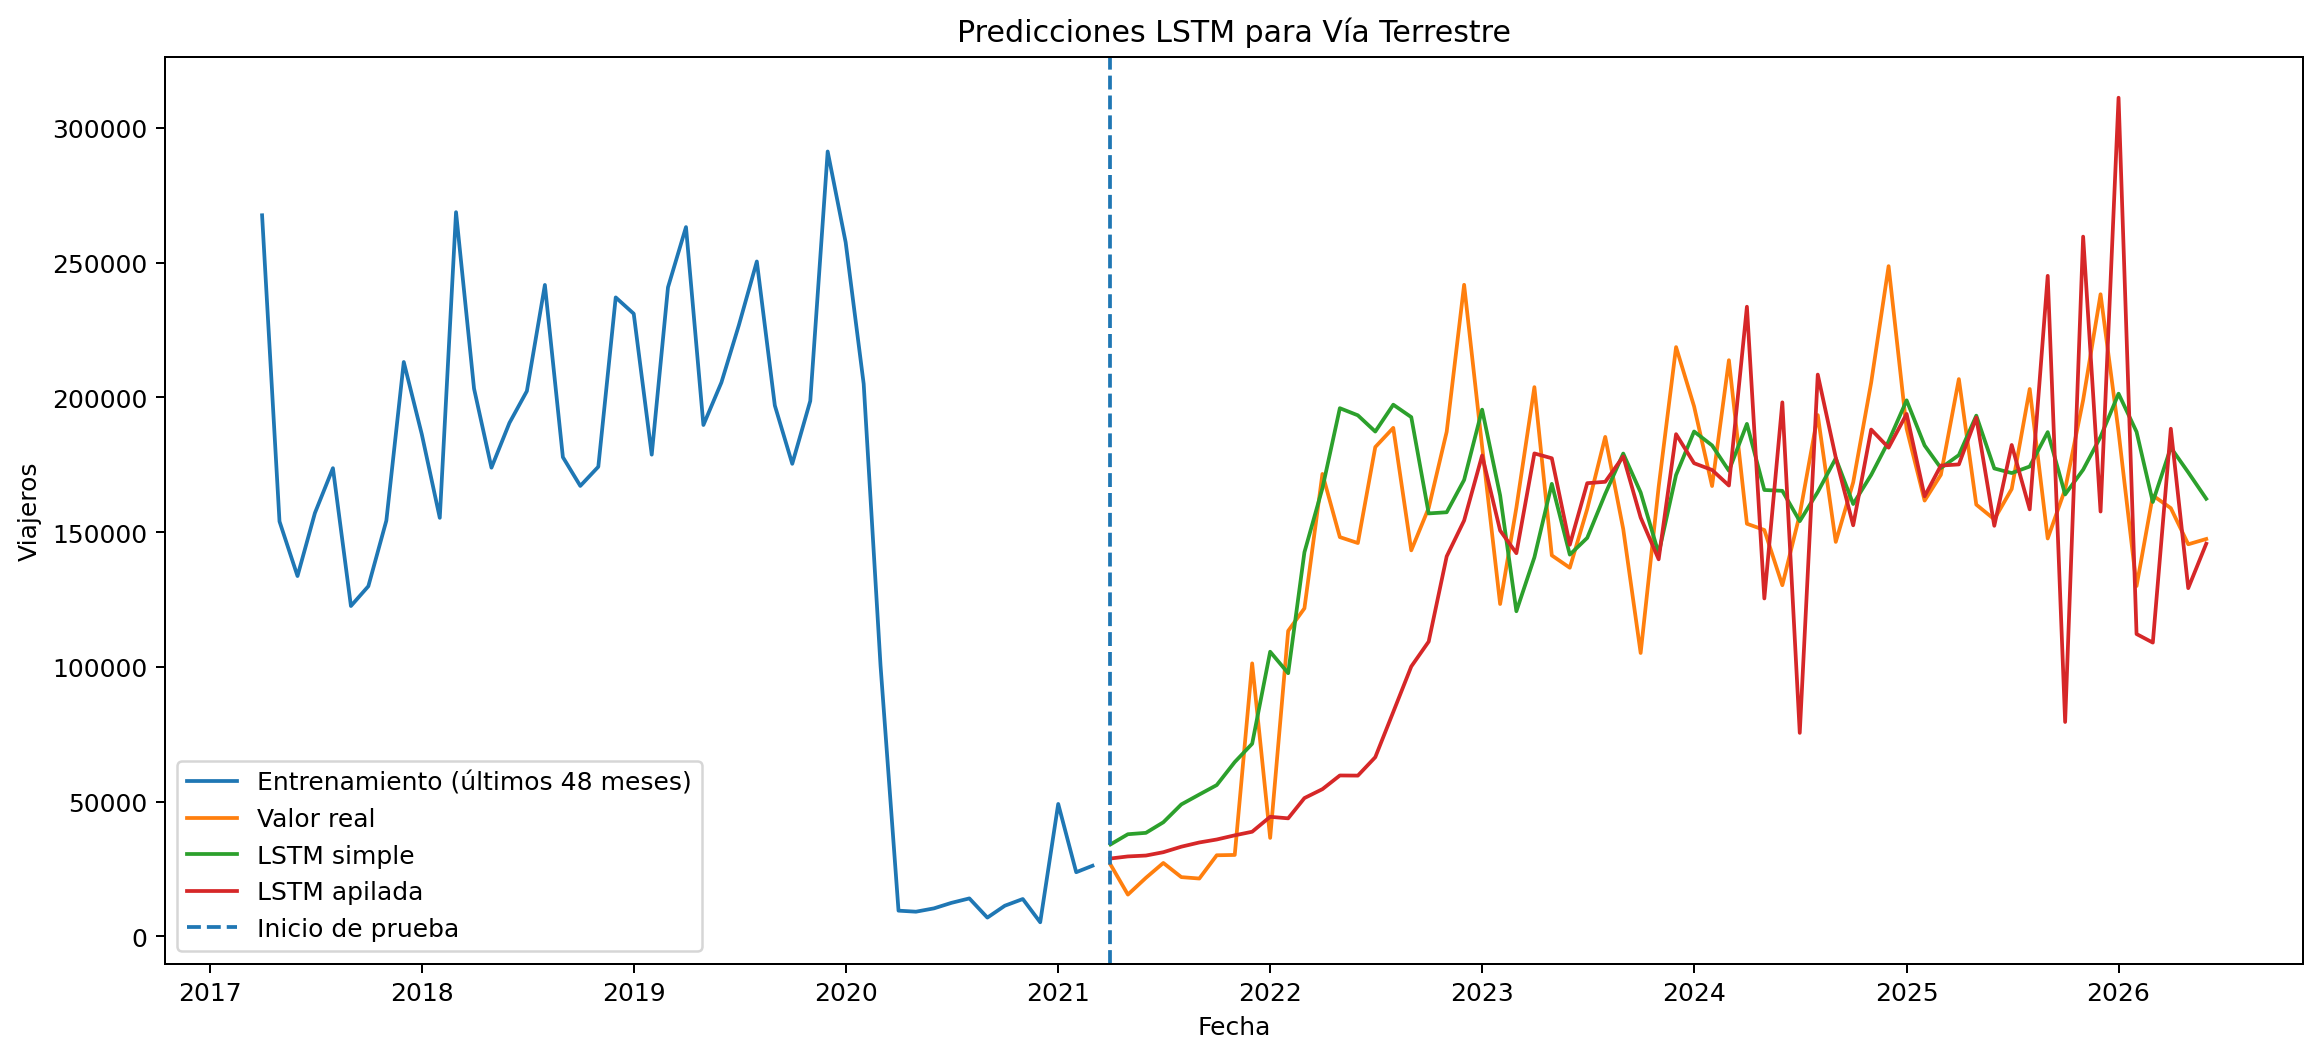

La LSTM simple obtuvo un MAE de 26,841.69 viajeros, un RMSE de 32,280.39 y un sMAPE de 23.22%. La LSTM apilada obtuvo un MAE de 39,317.52, un RMSE de 51,767.09 y un sMAPE de 31.32%.

La LSTM simple se adaptó más rápidamente al crecimiento de la serie durante la recuperación. La arquitectura apilada tardó más en alcanzar el nivel real y posteriormente generó varias sobreestimaciones y subestimaciones fuertes. Esto explica su RMSE considerablemente mayor.

### Pérdida de entrenamiento — Vía Terrestre

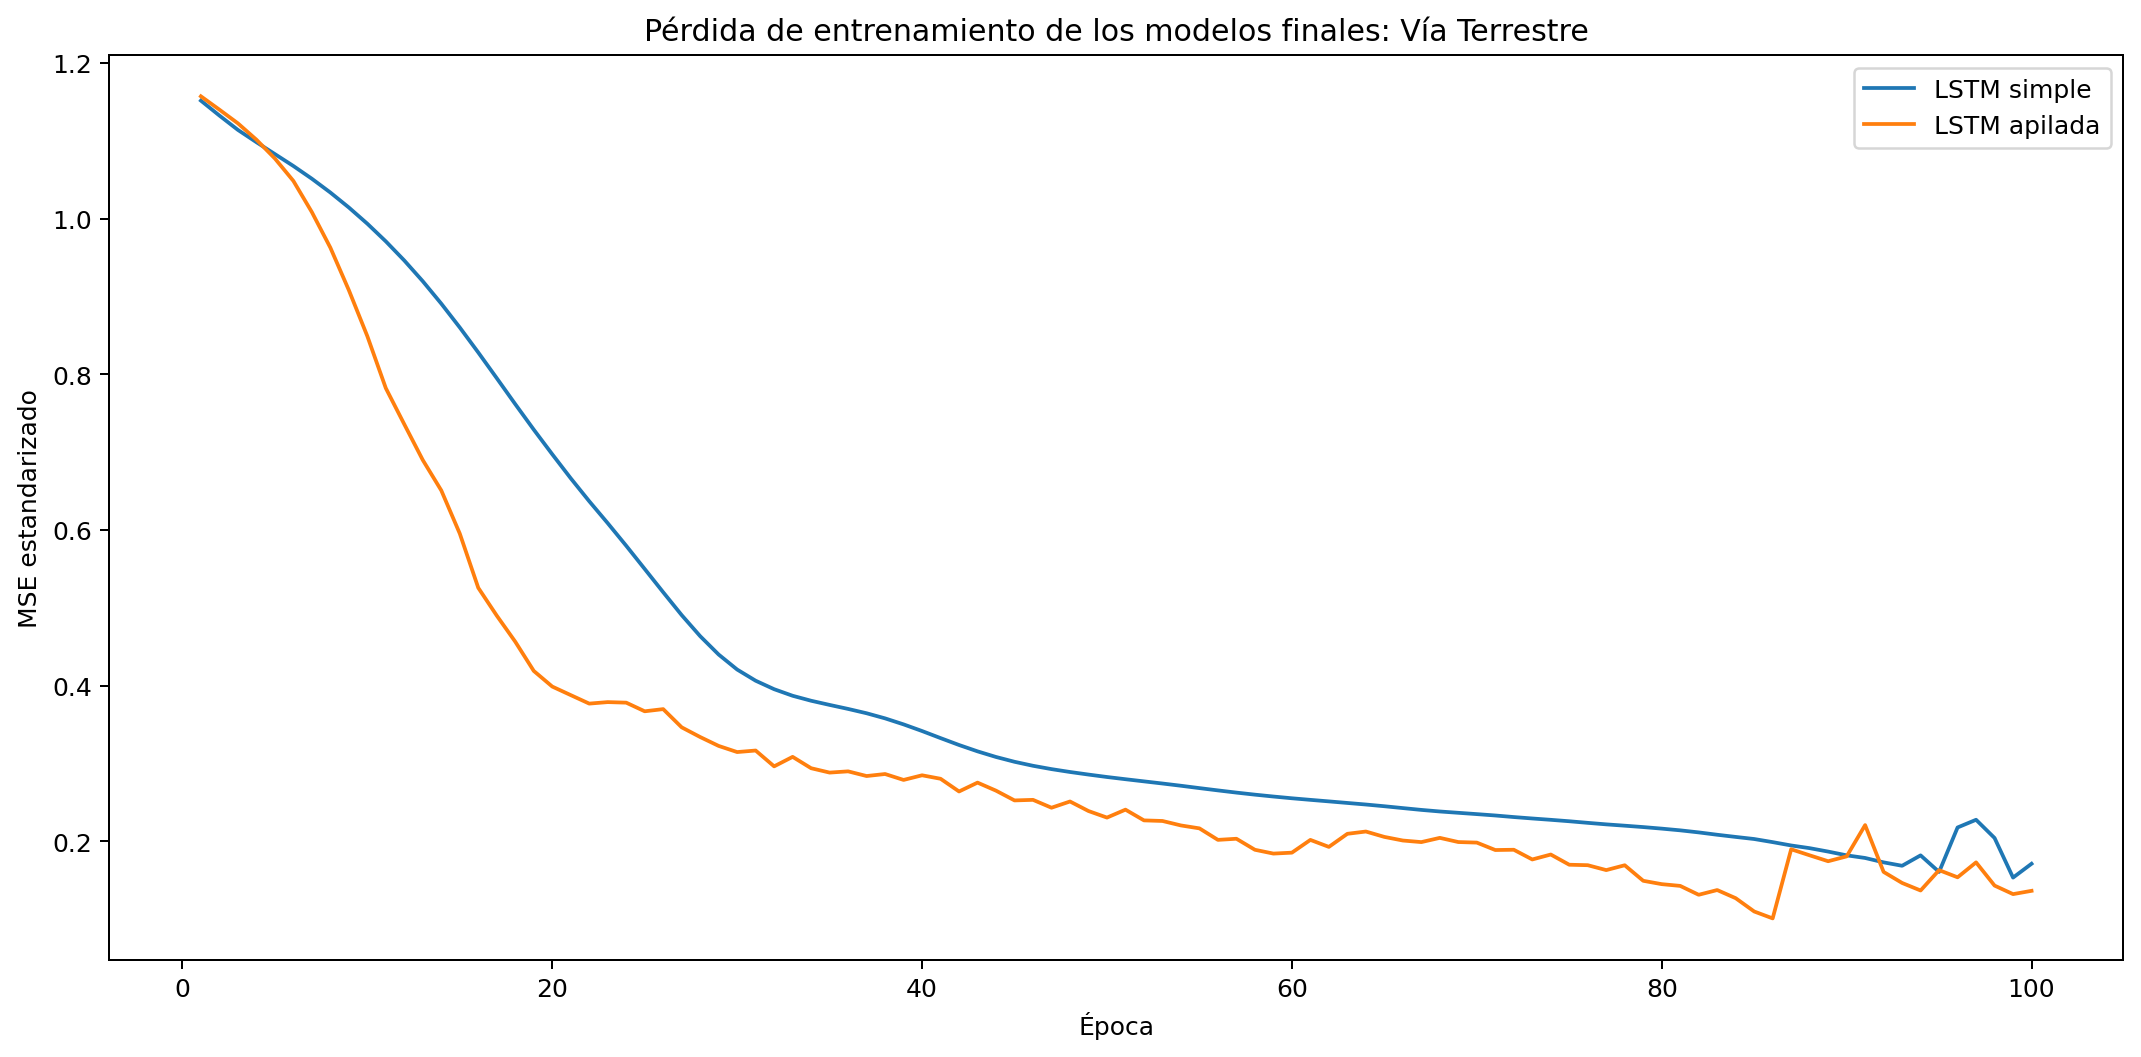

La LSTM simple alcanzó una pérdida de entrenamiento menor que la arquitectura apilada. En esta serie, la red de dos capas no aportó una mejora y mostró mayor sensibilidad a los cambios extremos.

## Conclusiones de los modelos LSTM

Se construyeron y tunearon dos modelos LSTM diferentes para cada una de las dos series. La LSTM simple fue la mejor arquitectura tanto para Vía Aérea como para Vía Terrestre.

En todos los casos se seleccionó una ventana de 24 meses. Esto indica que observar dos ciclos anuales completos fue útil para representar la tendencia y la estacionalidad. También se comprobó que una arquitectura más profunda no necesariamente generaliza mejor, ya que las LSTM apiladas tuvieron errores mayores en las dos series.

Los resultados de esta primera parte se conservaron sin volver a construir el análisis. A continuación se agrega la comparación con el Laboratorio 1, el análisis completo con catch22 y el modelo LSTM que incorpora estas características.

# Comparación con los modelos del Laboratorio 1

Para comparar los modelos se utilizaron los mismos conjuntos cronológicos de entrenamiento y prueba. El criterio principal fue el RMSE porque penaliza con mayor fuerza los errores grandes. El MAE se utilizó como apoyo para medir el error promedio en viajeros.

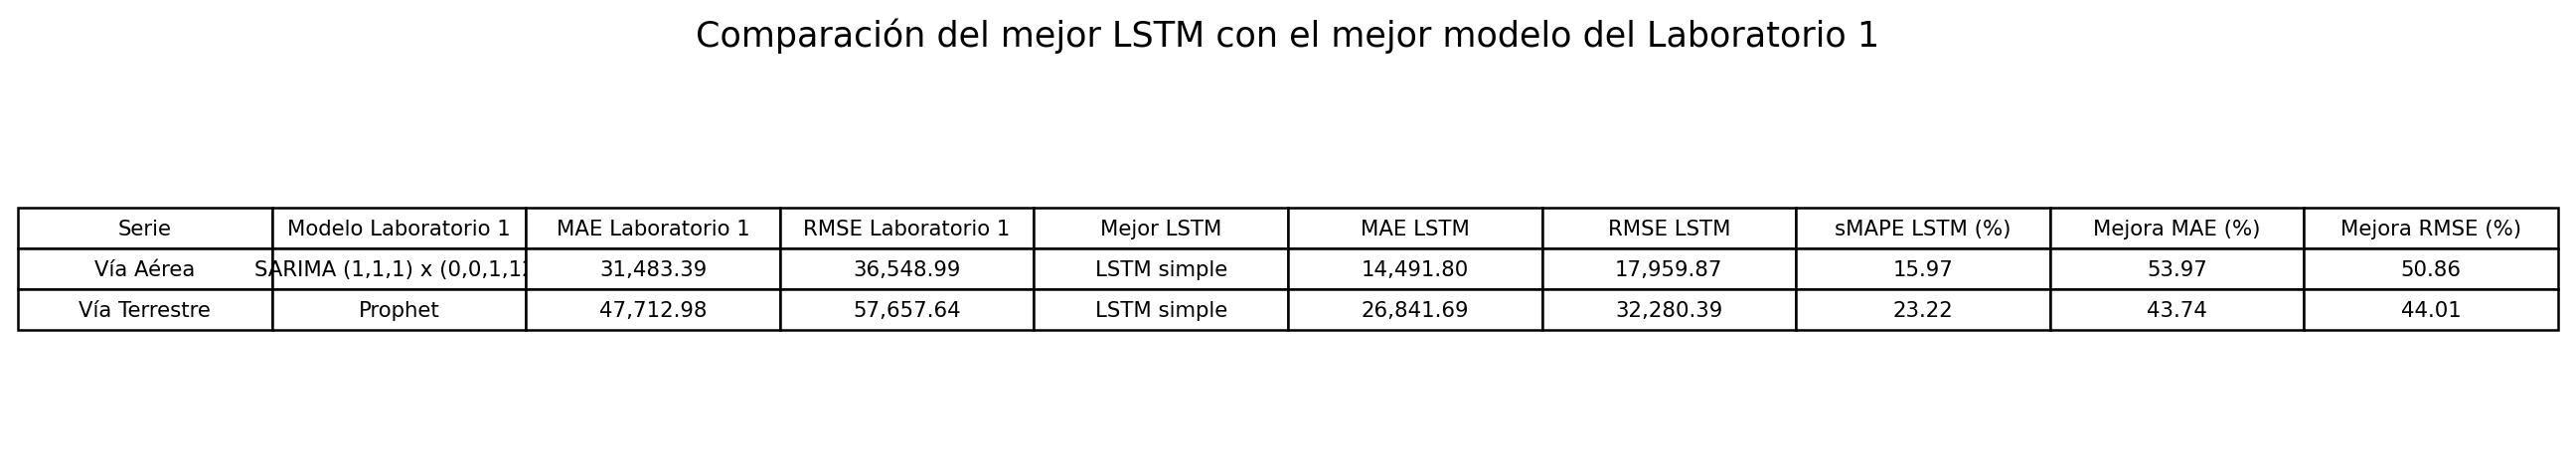

En Vía Aérea, la LSTM simple redujo el MAE de 31,483.39 a 14,491.80 viajeros y el RMSE de 36,548.99 a 17,959.87. Esto representa una mejora de 53.97% en MAE y 50.86% en RMSE frente al mejor SARIMA del Laboratorio 1.

En Vía Terrestre, la LSTM simple redujo el MAE de 47,712.98 a 26,841.69 viajeros y el RMSE de 57,657.64 a 32,280.39. La mejora fue de 43.74% en MAE y 44.01% en RMSE frente a Prophet.

Por lo tanto, las LSTM simples predijeron mejor las dos series estudiadas. La conclusión se basa en que obtuvieron simultáneamente un MAE y un RMSE menores usando exactamente el mismo período de prueba.

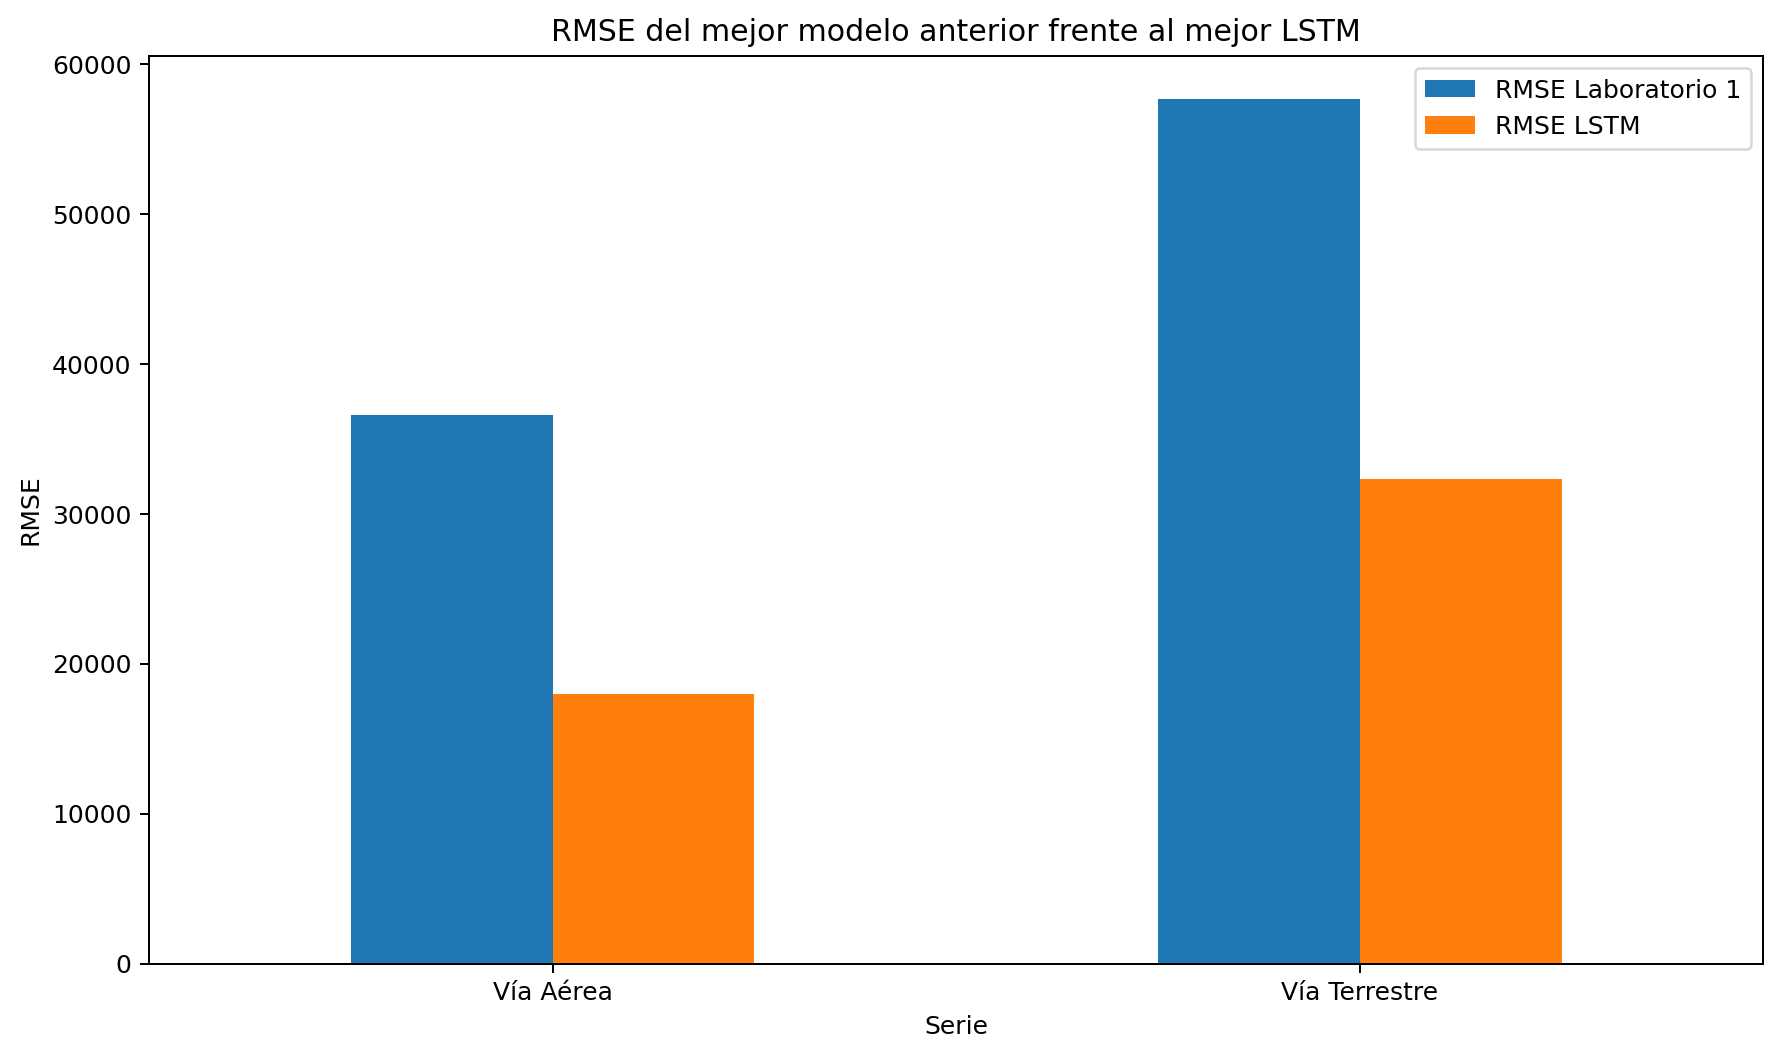

# Análisis de similitud con catch22

## Idea principal

catch22 resume una serie temporal mediante 22 características que describen su dinámica. Estas características representan aspectos como autocorrelación, periodicidad, transiciones, eventos extremos, fluctuaciones, entropía y dificultad de predicción local.

Su utilidad es que permite comparar series de tamaños y niveles distintos mediante una representación común. En lugar de comparar directamente los valores mensuales, cada serie se convierte en una fila de 22 números. La extracción quedó versionada en `src/catch22_core.py` y el análisis completo en `src/catch22_analysis.py`.

## Matriz de características y estandarización

Se utilizaron las siete series construidas en el Laboratorio 1: la serie total, las tres vías de ingreso y las tres regiones principales. Se obtuvo una matriz de 7 filas por 22 columnas.

Antes de aplicar PCA, clustering y distancias, cada característica se estandarizó para que tuviera media cero y desviación estándar uno. Esto evita que una característica domine únicamente porque sus valores numéricos son más grandes.

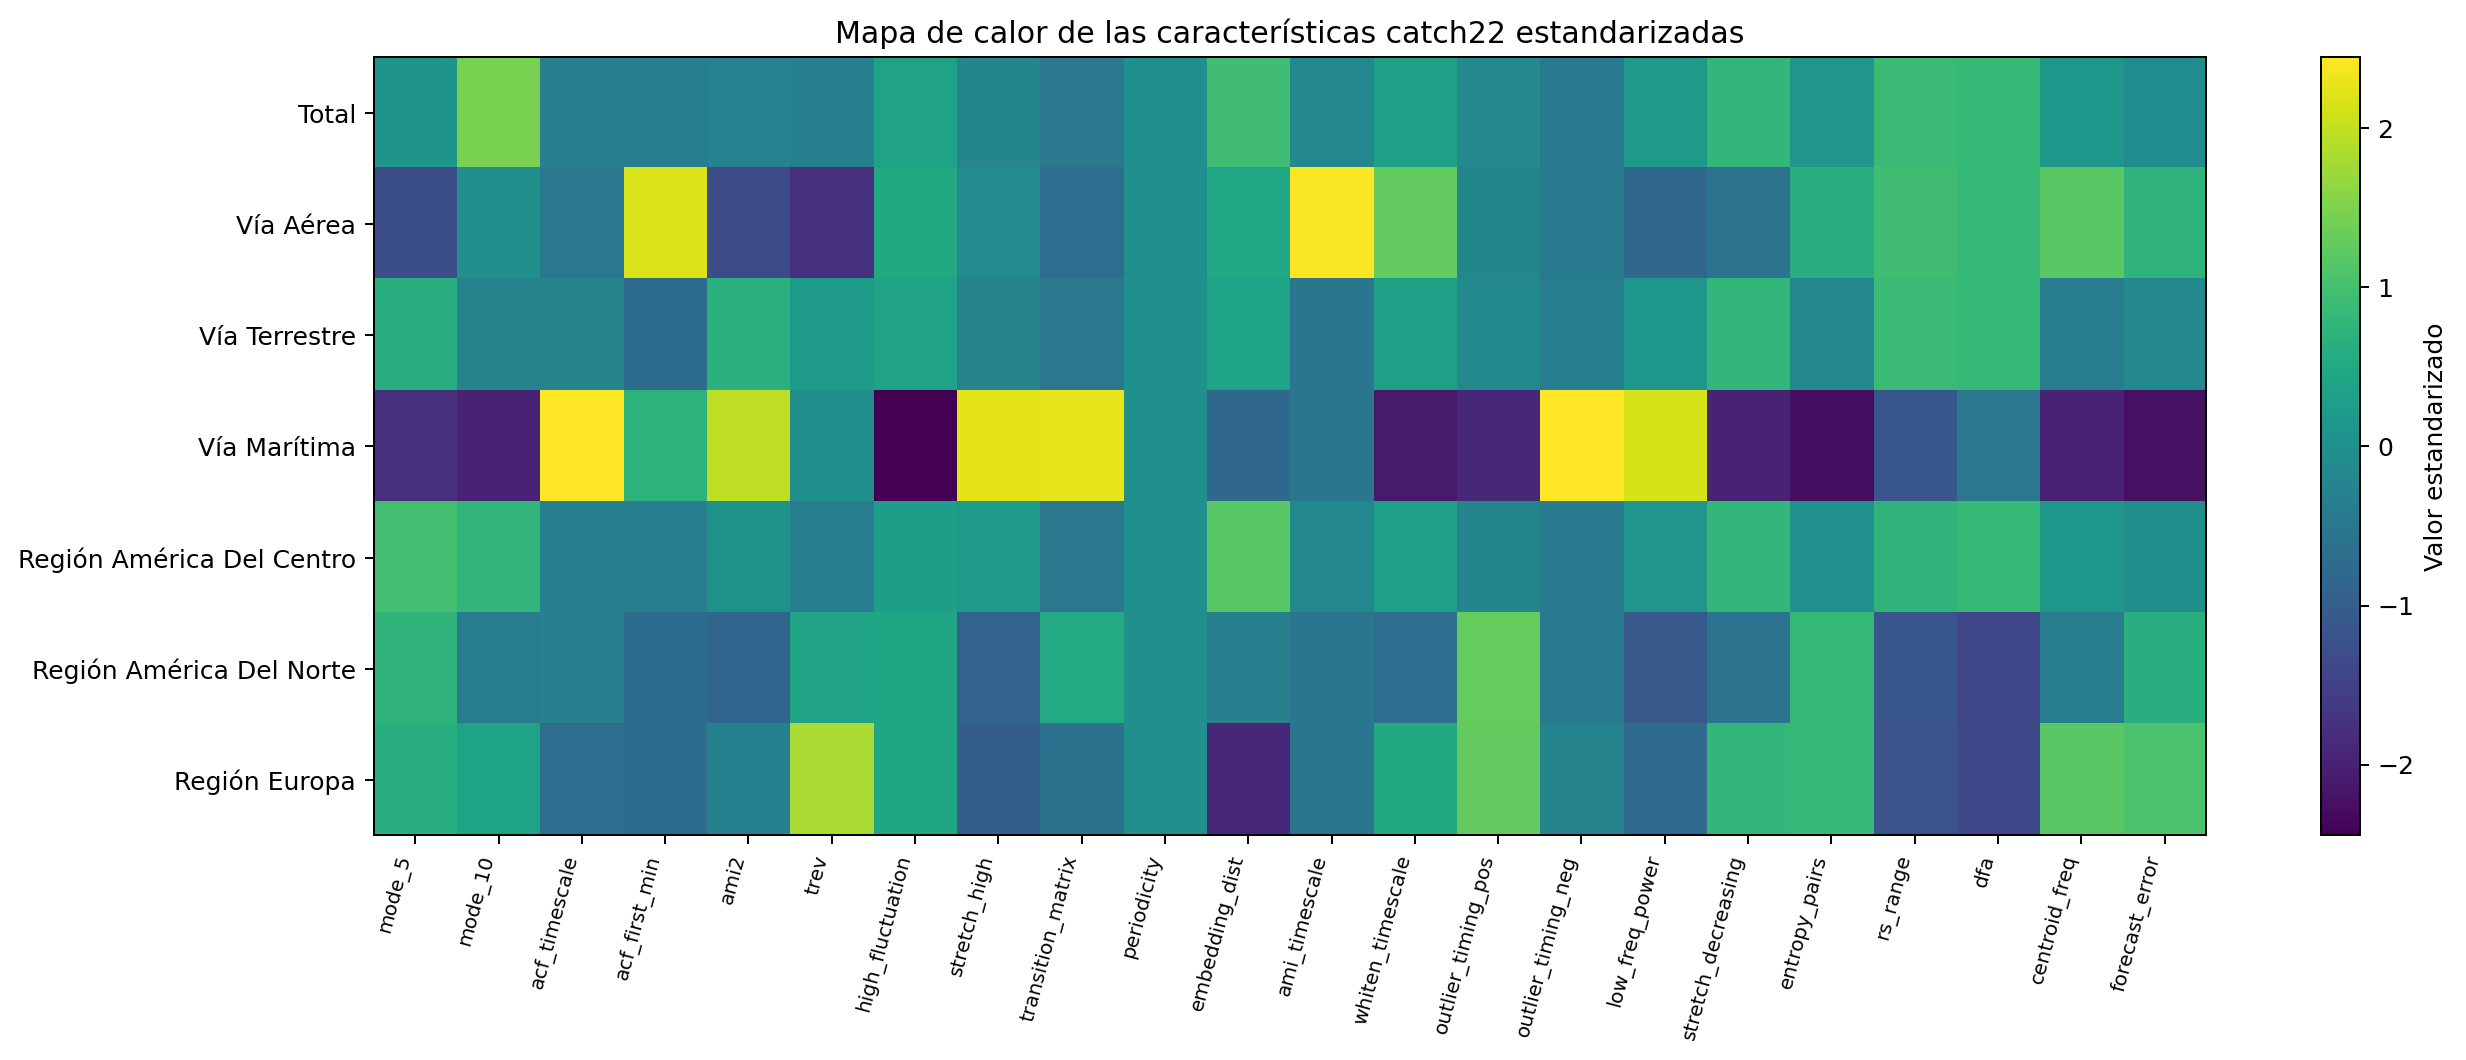

El mapa de calor muestra que Vía Marítima tiene un patrón muy diferente al resto en varias características al mismo tiempo. Sobresale en la escala de autocorrelación, las rachas sobre la media, la matriz de transiciones y el momento de eventos extremos negativos. También presenta valores bajos en fluctuación, entropía de transiciones y error de pronóstico local.

Las filas de Total y Región América Del Centro se parecen en la mayoría de las columnas. Vía Terrestre también mantiene un patrón cercano a estas dos series, aunque no es idéntico.

## Análisis de Componentes Principales

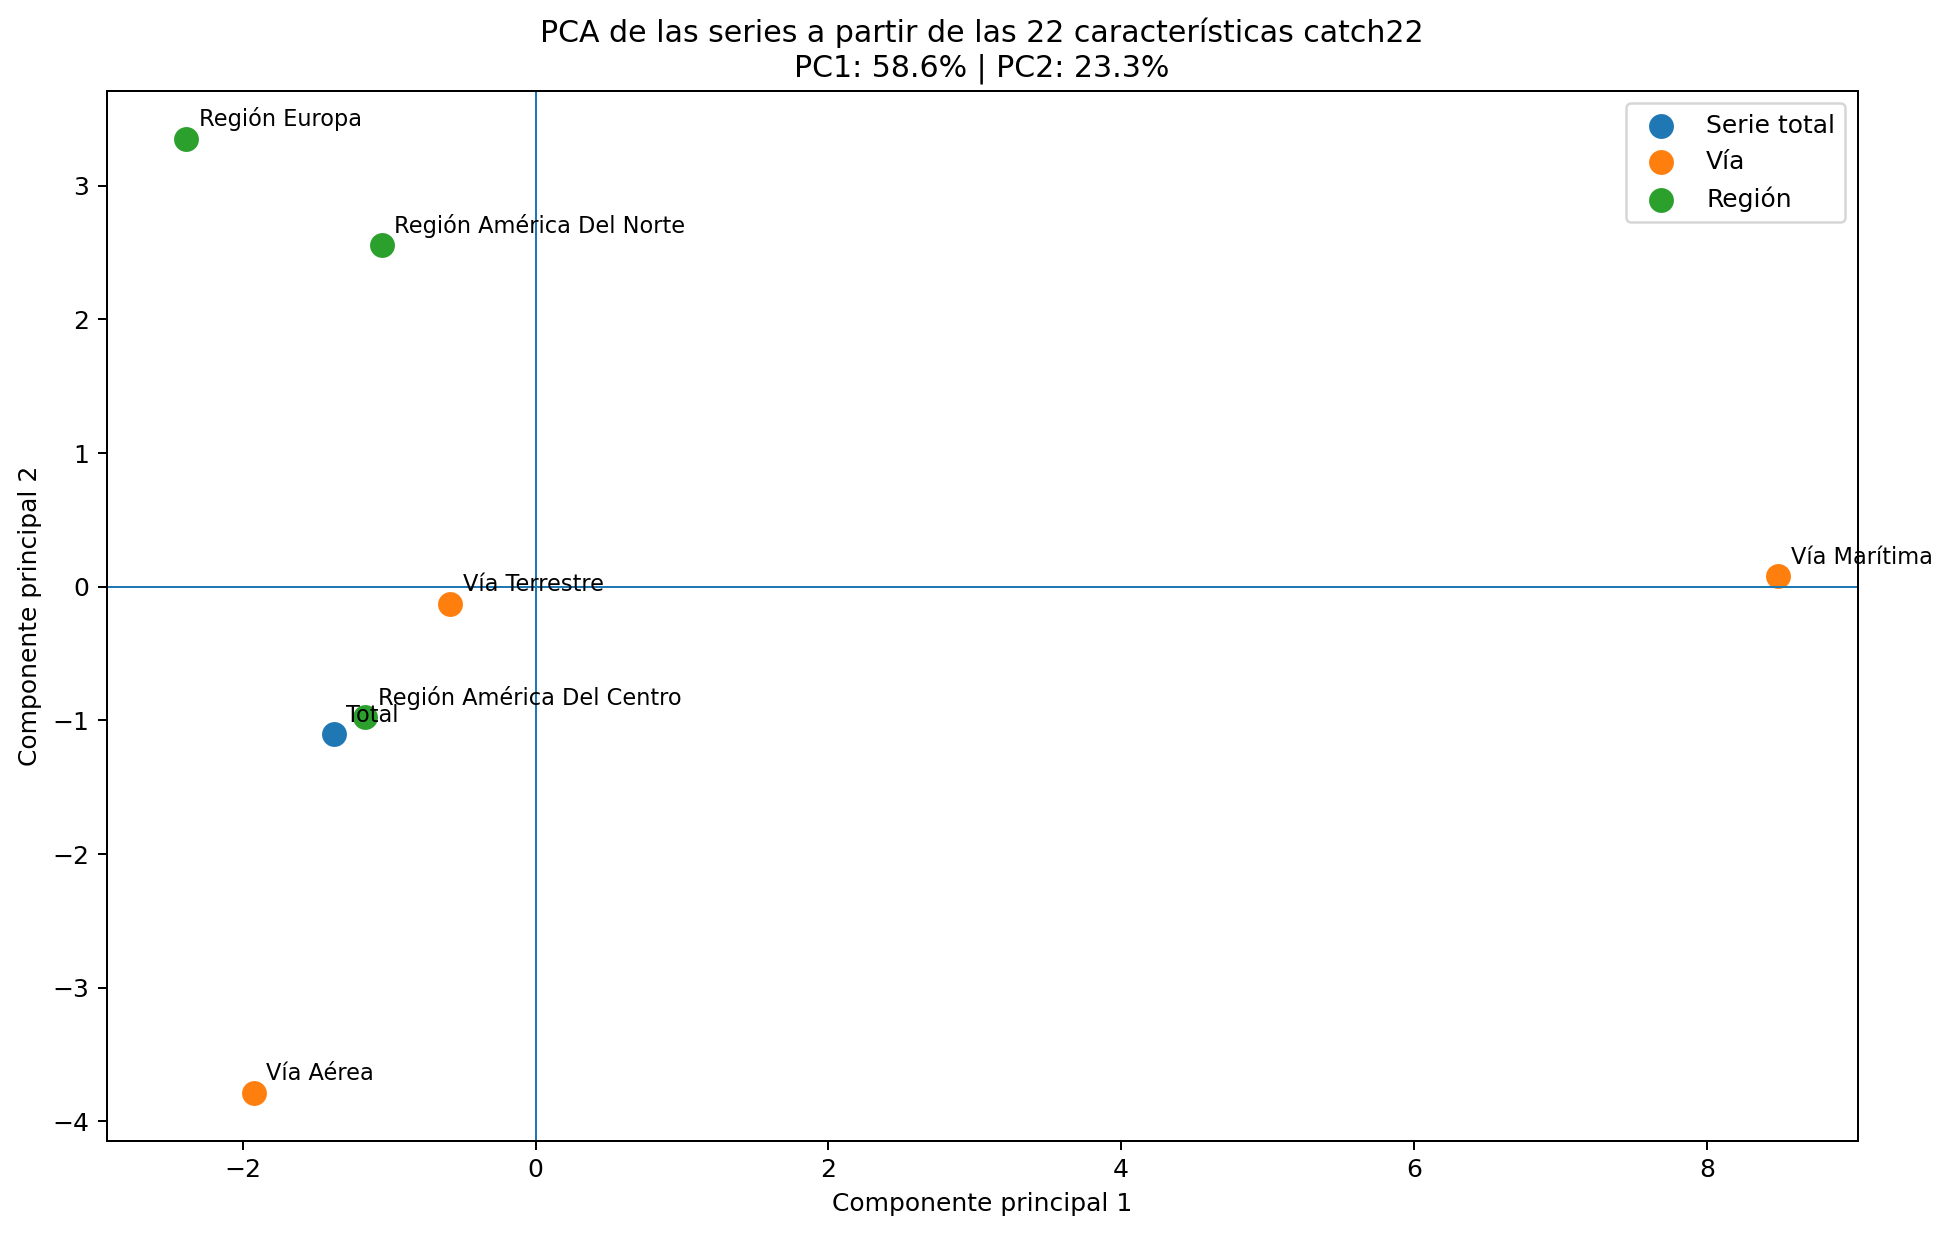

Los dos primeros componentes explicaron 81.9% de la variación total: 58.6% en PC1 y 23.3% en PC2. Esto permite resumir la mayor parte de las diferencias en un plano de dos dimensiones.

Vía Marítima quedó muy separada en el extremo positivo de PC1, por lo que su comportamiento es el más distinto. Total y Región América Del Centro aparecen casi juntas. Vía Terrestre también se encuentra cerca de ese grupo. Región América Del Norte y Región Europa se separan principalmente por PC2, mientras que Vía Aérea ocupa el extremo negativo de ese componente.

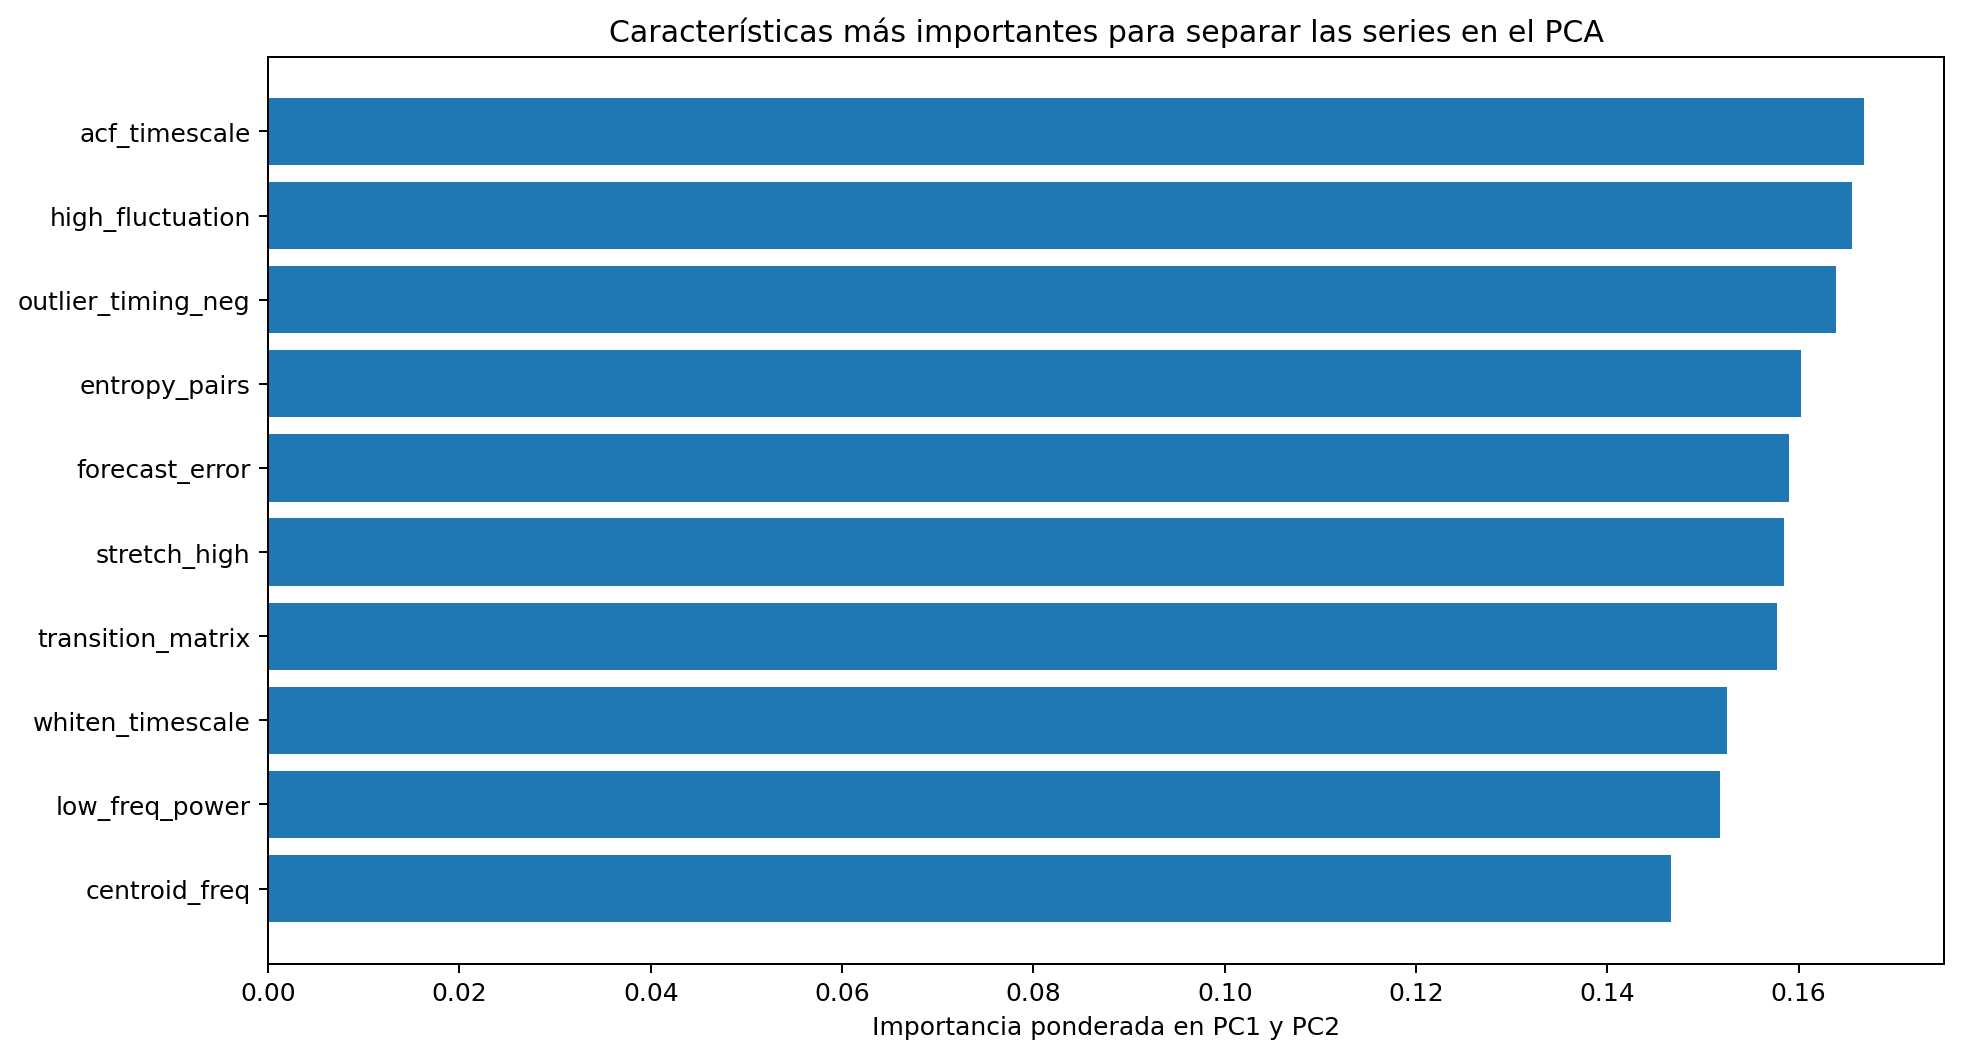

Las características con mayor importancia para diferenciar las series fueron:

- `acf_timescale`: duración de la dependencia temporal o persistencia.
- `high_fluctuation`: proporción de cambios consecutivos grandes.
- `outlier_timing_neg`: distribución temporal de eventos extremos negativos.
- `entropy_pairs`: diversidad de transiciones entre estados.
- `forecast_error`: error de una predicción local simple.
- `stretch_high`: duración de rachas consecutivas sobre la media.
- `transition_matrix`: estructura de transiciones entre niveles.

Esto indica que las diferencias no se explican solamente por tendencia o volumen, sino también por la memoria, las rachas, la irregularidad y la predictibilidad de cada serie.

## Clustering

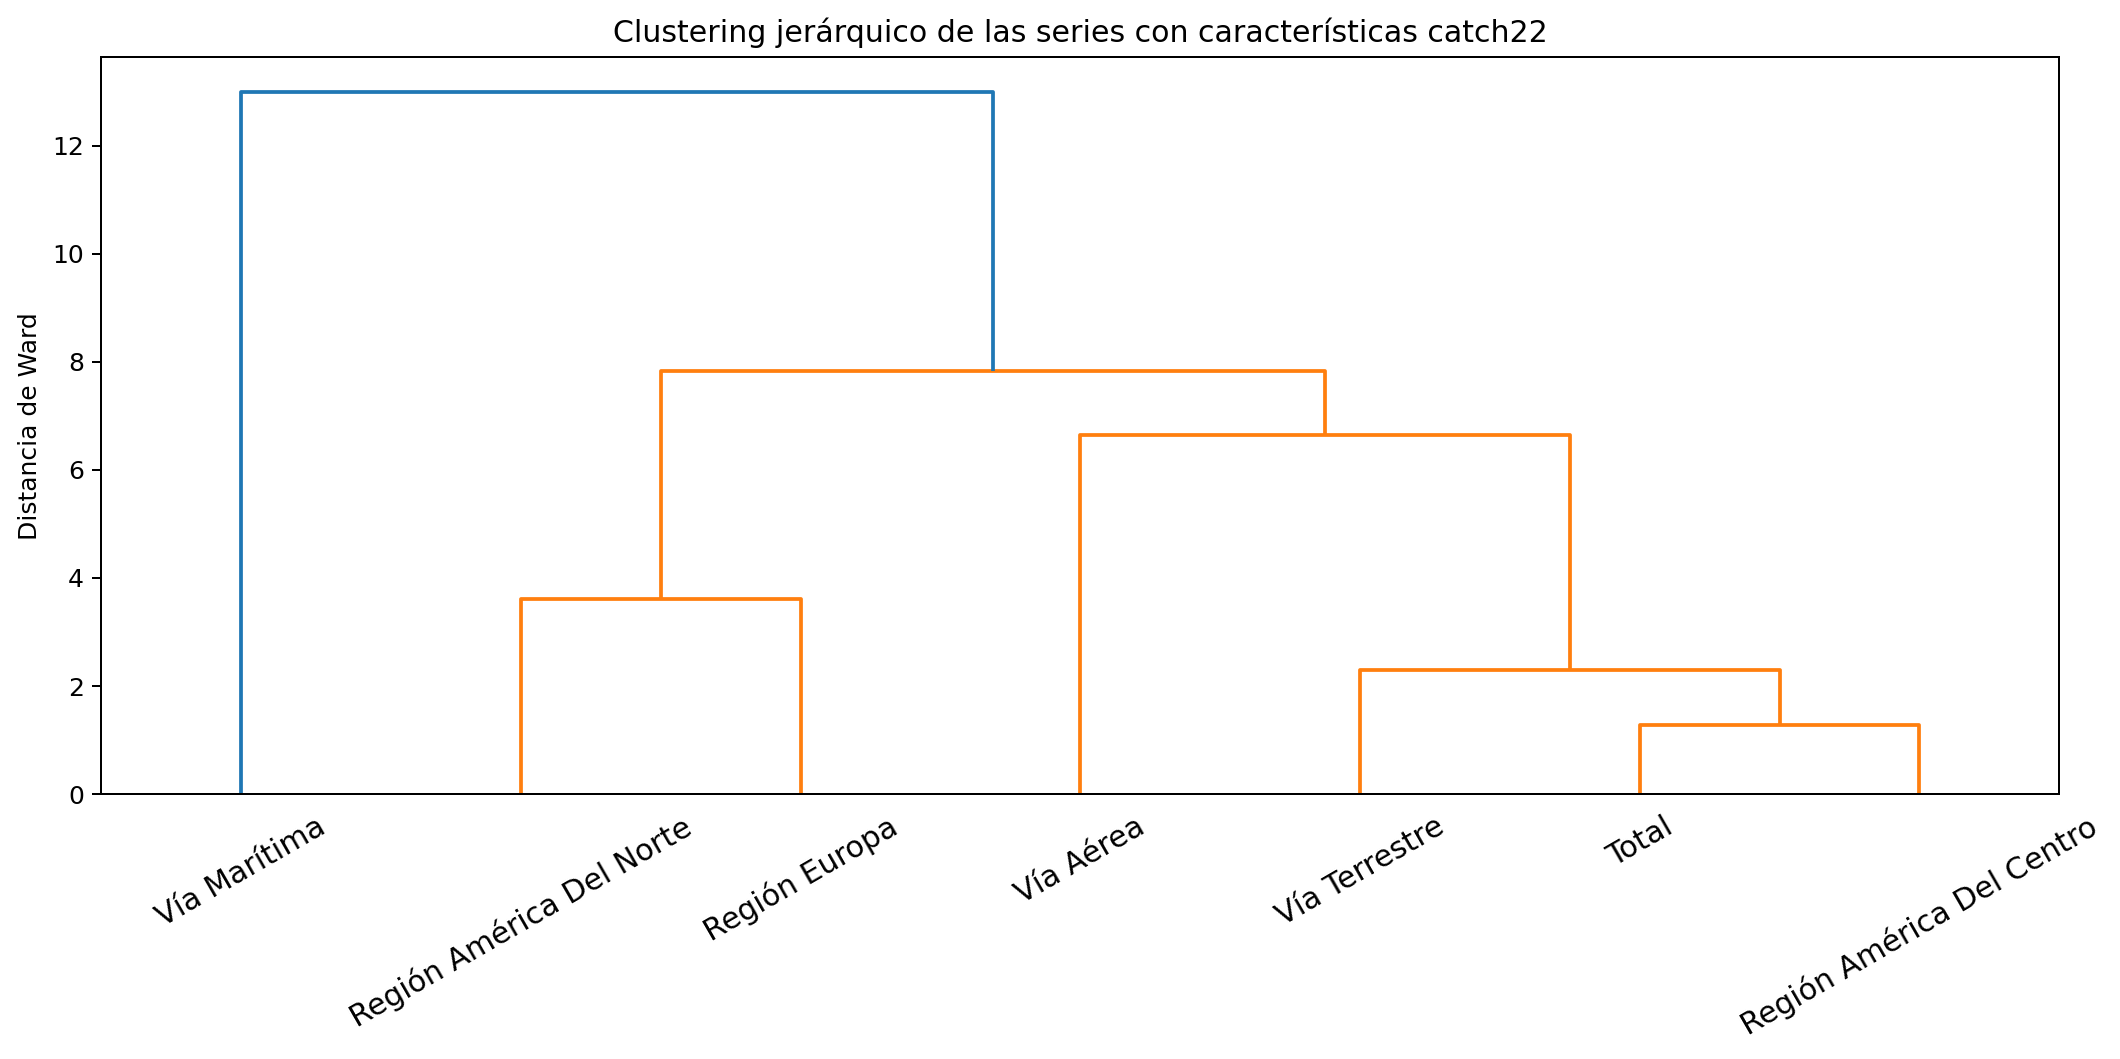

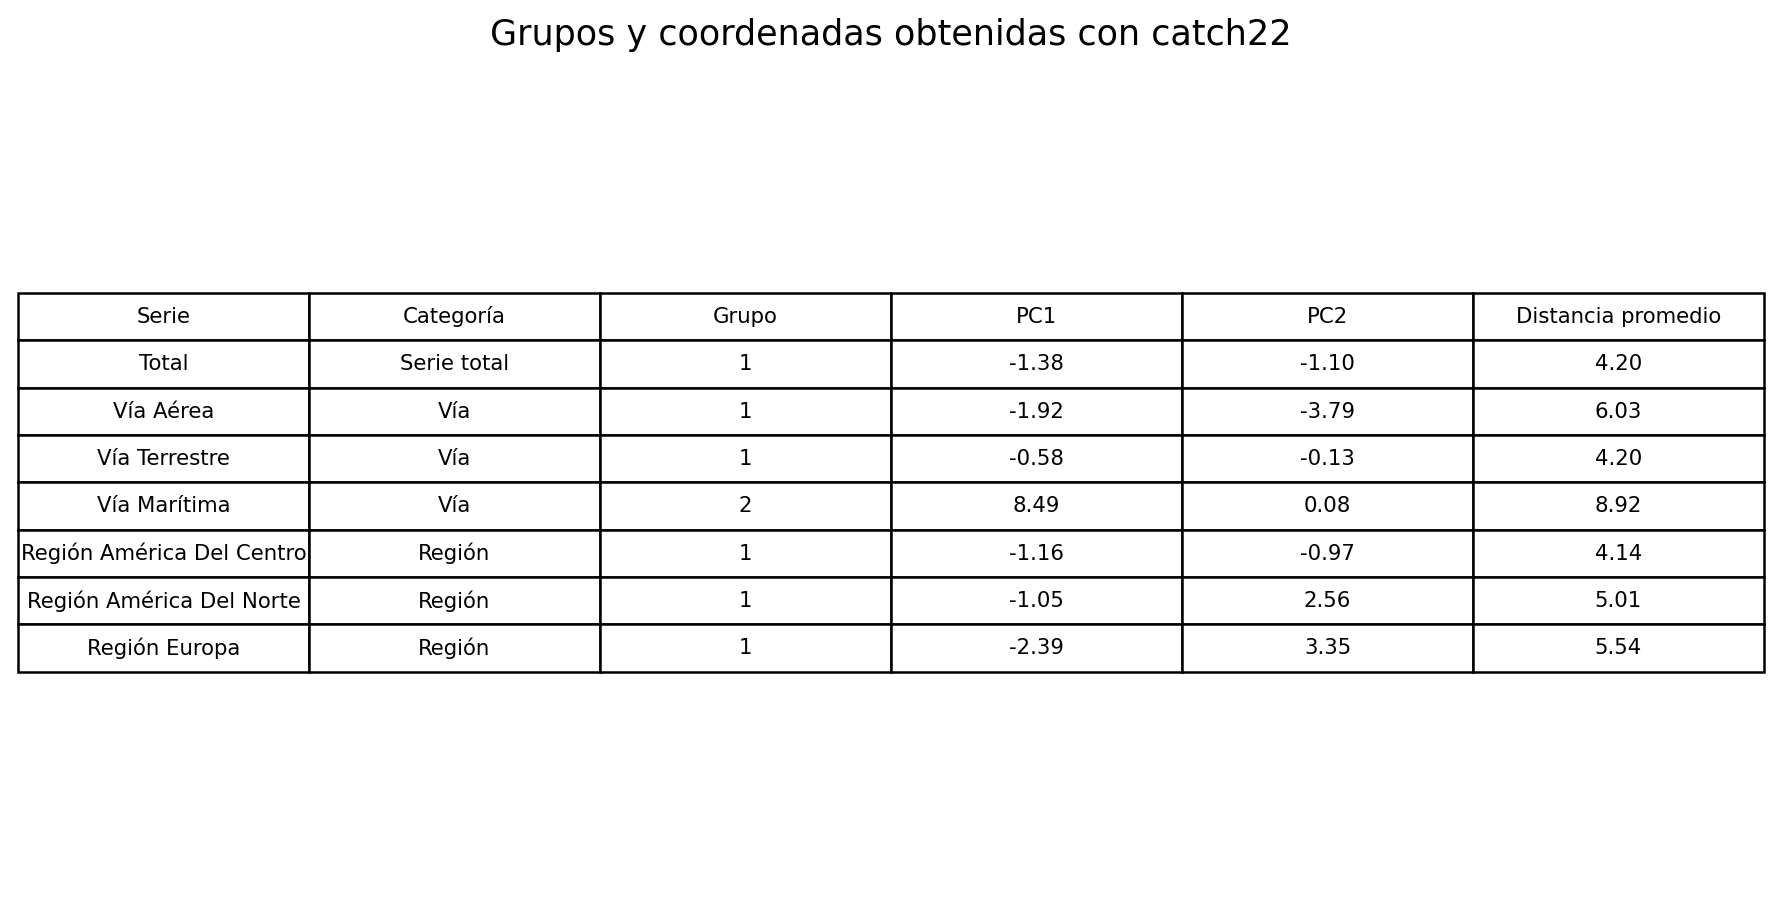

El mejor resultado según el coeficiente silhouette fue una división en dos grupos, con un valor de 0.471.

El primer grupo contiene la serie Total, Vía Aérea, Vía Terrestre y las tres regiones. El segundo grupo contiene únicamente Vía Marítima. Por lo tanto, el principal grupo natural separa una serie escasa y muy irregular del resto de series con actividad mensual más continua.

Las series de una misma categoría no siempre se agrupan entre sí. Las tres regiones quedaron en el mismo grupo general, pero América Del Norte y Europa se separan de América Del Centro en el PCA. Entre las vías, Aérea y Terrestre están en el grupo principal, mientras que Marítima forma un grupo aparte.

## Correlaciones entre características

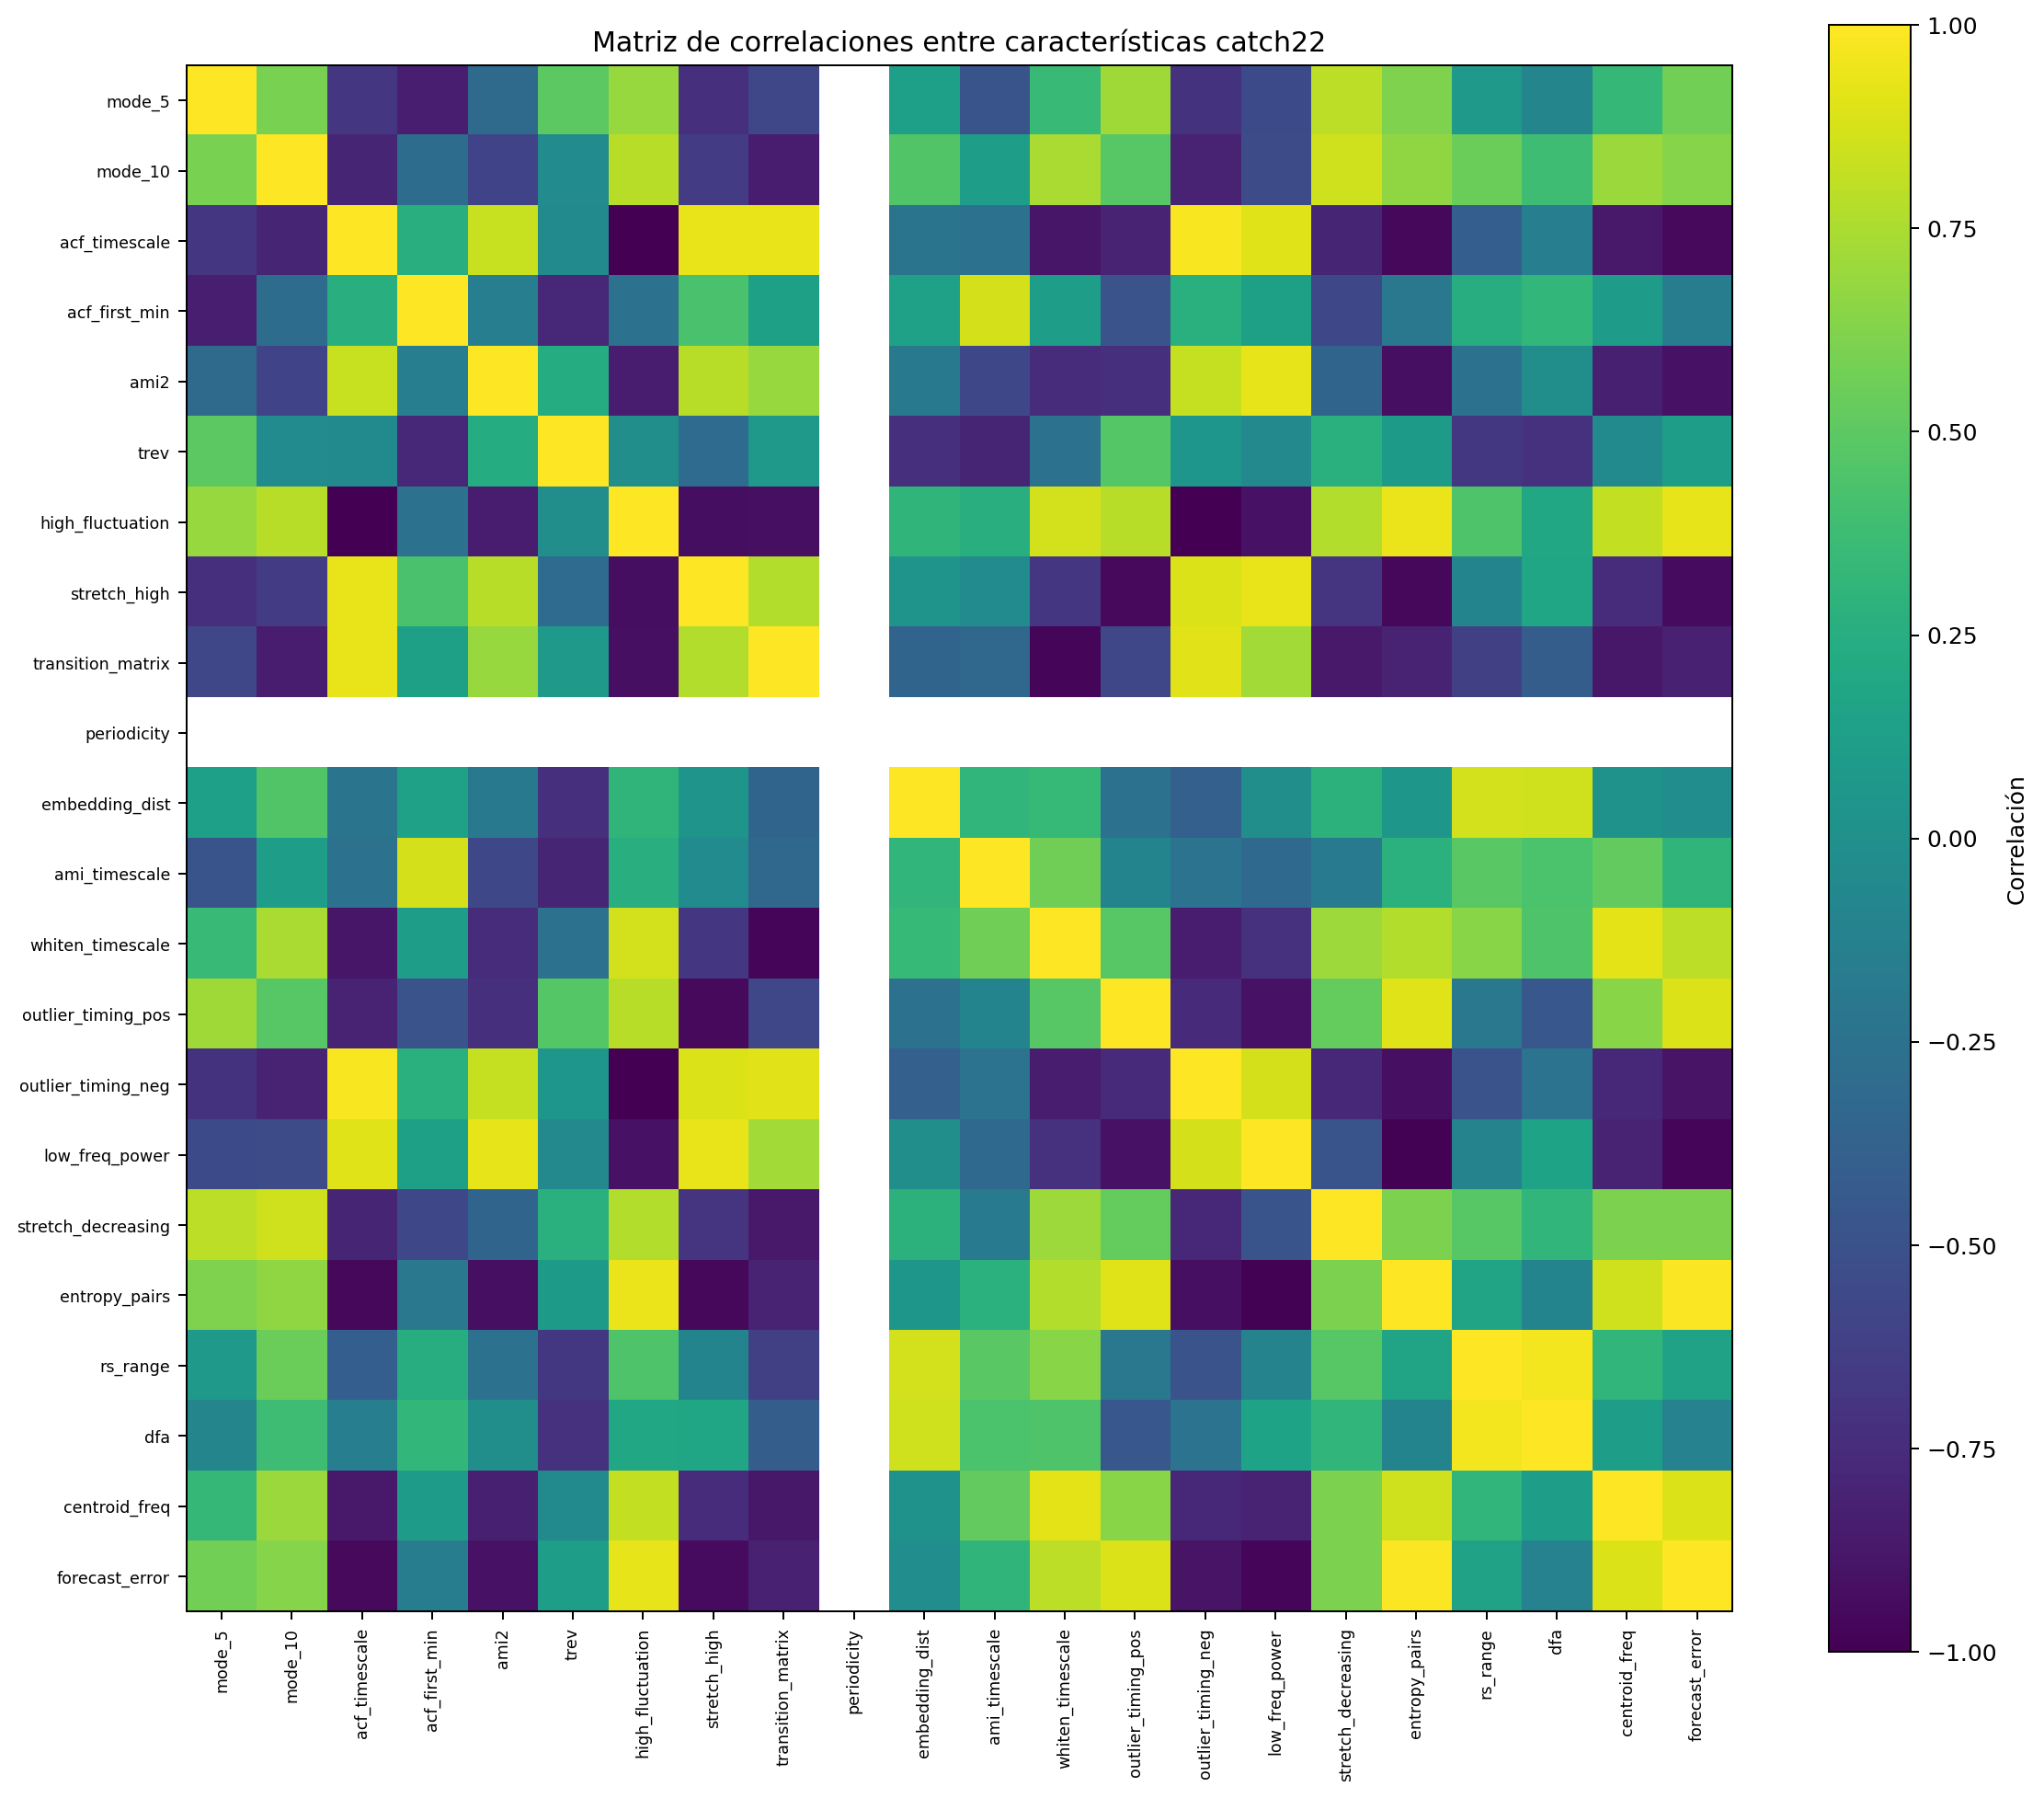

La matriz permite identificar características que cambian de forma parecida entre las series. Algunas medidas de persistencia, frecuencia, fluctuación y predictibilidad están relacionadas, por lo que no todas aportan información completamente independiente.

Esta interpretación debe tomarse como exploratoria porque solo se tienen siete series. Una correlación alta con tan pocas observaciones puede cambiar si se agregan más categorías.

## Distancias entre series

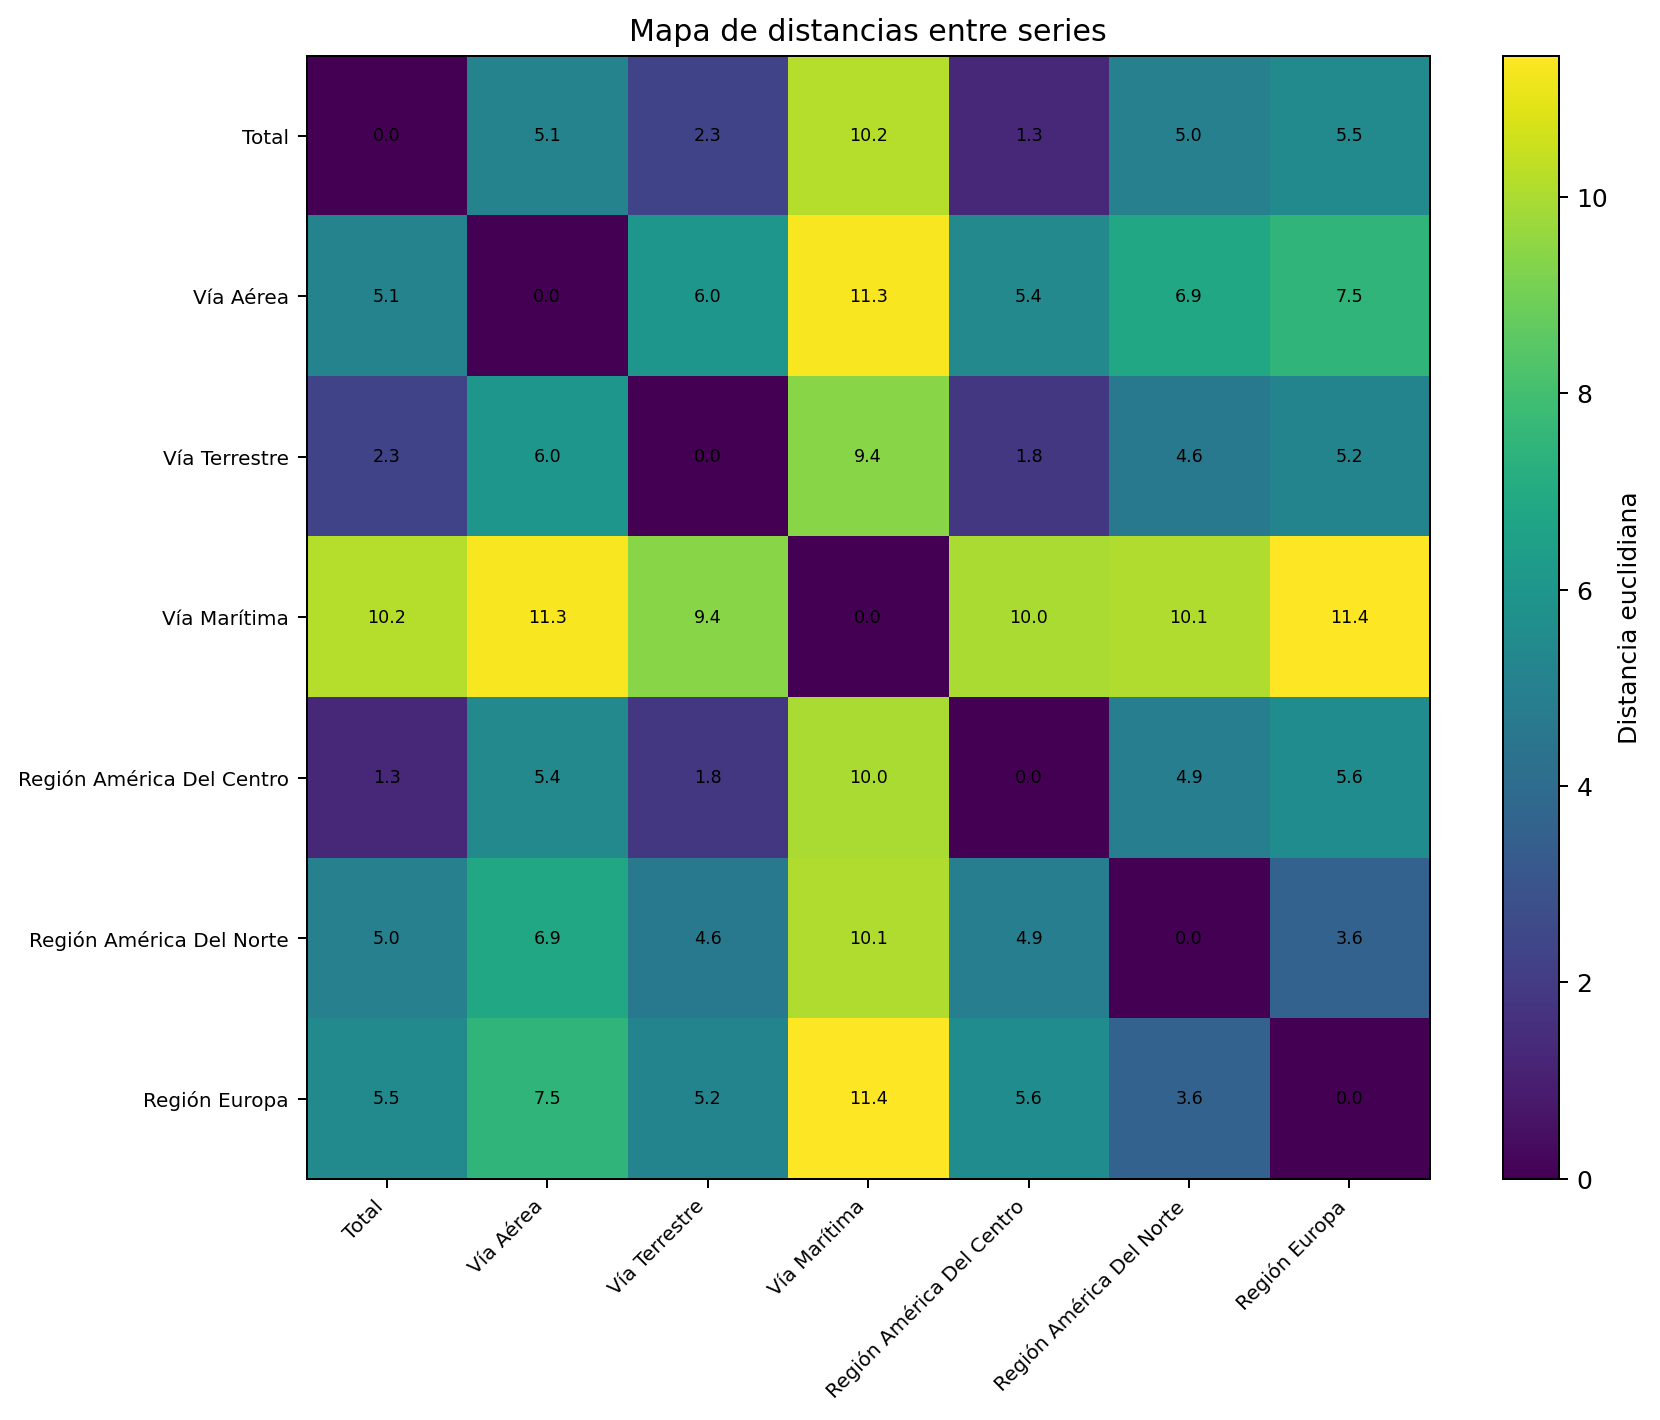

El par más parecido fue Total y Región América Del Centro, con una distancia de 1.28. Esto tiene sentido porque América Del Centro es la región que más aporta al total y ambas series comparten cambios de tendencia, estacionalidad e impacto de la pandemia.

El par más diferente fue Vía Marítima y Región Europa, con una distancia de 11.44. Vía Marítima también tuvo la mayor distancia promedio respecto al resto, por lo que se considera la serie más atípica.

## Comparación con el análisis exploratorio anterior

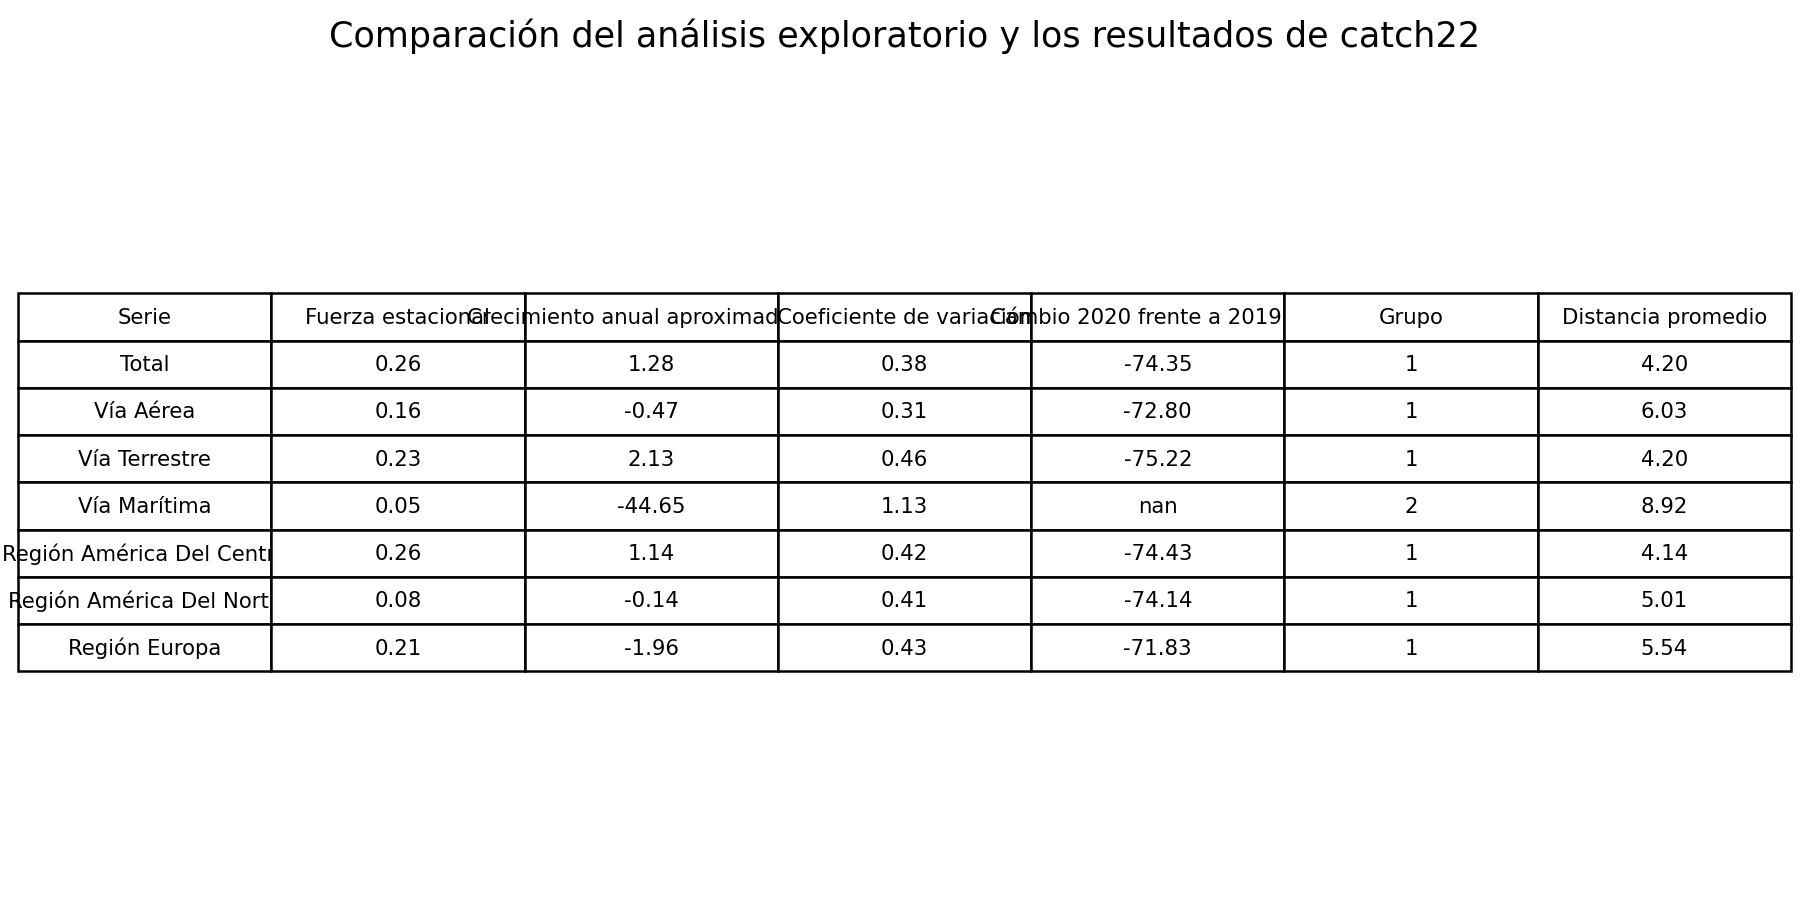

Los resultados de catch22 son consistentes con varios hallazgos del análisis exploratorio:

- Vía Marítima ya había presentado el coeficiente de variación más alto, igual a 1.134, y una caída anual aproximada muy fuerte. catch22 confirma que no solo es más volátil, sino que su estructura temporal completa es distinta.
- Total y Región América Del Centro tenían fuerzas estacionales muy parecidas, de 0.256 y 0.263. catch22 las identificó como el par más similar.
- Vía Terrestre tenía la mayor tendencia de crecimiento y la mayor caída durante la pandemia. En catch22 se mantiene cerca de Total y América Del Centro, pero con diferencias en fluctuación y persistencia.
- América Del Norte y Europa no muestran el mismo patrón que América Del Centro, aunque las tres pertenezcan a la categoría de regiones.

Los agrupamientos son consistentes con la tendencia, estacionalidad, volatilidad y efecto de la pandemia observados antes. Sin embargo, catch22 agrega información sobre autocorrelación, transiciones, entropía y predictibilidad local que no se veía directamente en las gráficas tradicionales.

## Tres descubrimientos obtenidos con catch22

1. Total y Región América Del Centro son el par más parecido de forma cuantitativa. En el análisis anterior se observaba una relación visual, pero no se tenía una distancia que confirmara que eran las más cercanas.

2. Vía Marítima no es atípica solamente por su volumen bajo o su coeficiente de variación. Se separa al combinar diferencias en persistencia, rachas, transiciones, entropía y eventos extremos.

3. Las series de una misma categoría no necesariamente tienen la misma dinámica. Las regiones pertenecen al mismo grupo amplio, pero América Del Norte y Europa se separan de América Del Centro en PC2. En las vías, Marítima forma un grupo diferente a Aérea y Terrestre.

4. Las características más útiles fueron medidas de memoria, fluctuación, eventos extremos y error local. Esto muestra que para distinguir series importa tanto la forma en que cambian como su tendencia y estacionalidad.

# Modelo LSTM con características catch22

Para probar si las características podían mejorar la predicción, se construyó un modelo híbrido para Vía Aérea. Se conservó la ventana de 24 meses del mejor modelo anterior.

La primera rama procesa la secuencia mensual con una LSTM. La segunda rama procesa las 22 características catch22 calculadas sobre la misma ventana. Las dos representaciones se unen antes de generar la predicción de un mes adelante.

El tuneo probó diferentes tamaños para la rama de catch22, valores de dropout y tasas de aprendizaje. La selección se realizó con el menor RMSE de validación, usando los mismos últimos 36 meses del entrenamiento.

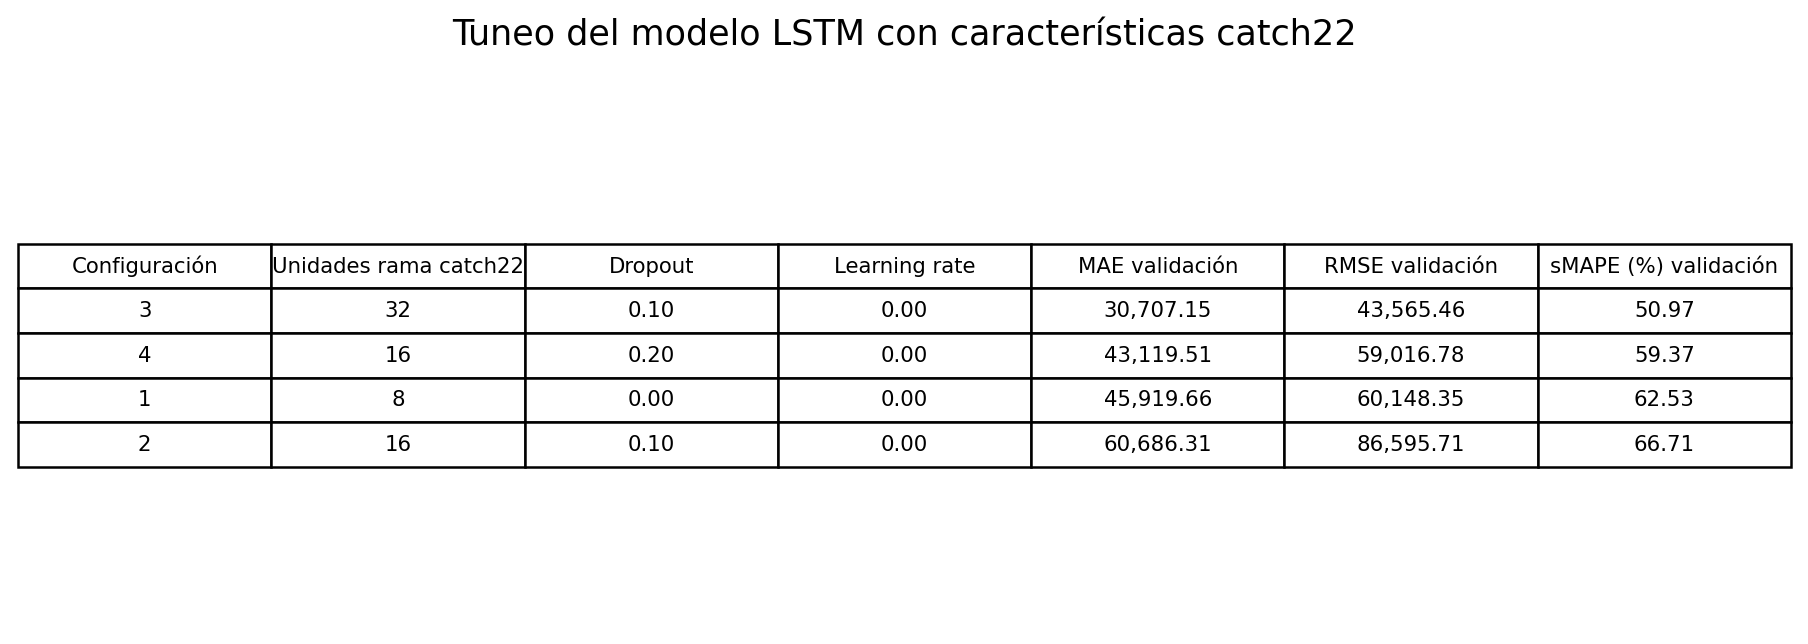

La mejor configuración de validación utilizó 32 unidades en la rama de catch22, dropout de 0.10 y una tasa de aprendizaje de 0.003. Después del tuneo, el modelo se volvió a entrenar con todo el conjunto de entrenamiento y se evaluó sobre el mismo período de prueba que la LSTM simple.

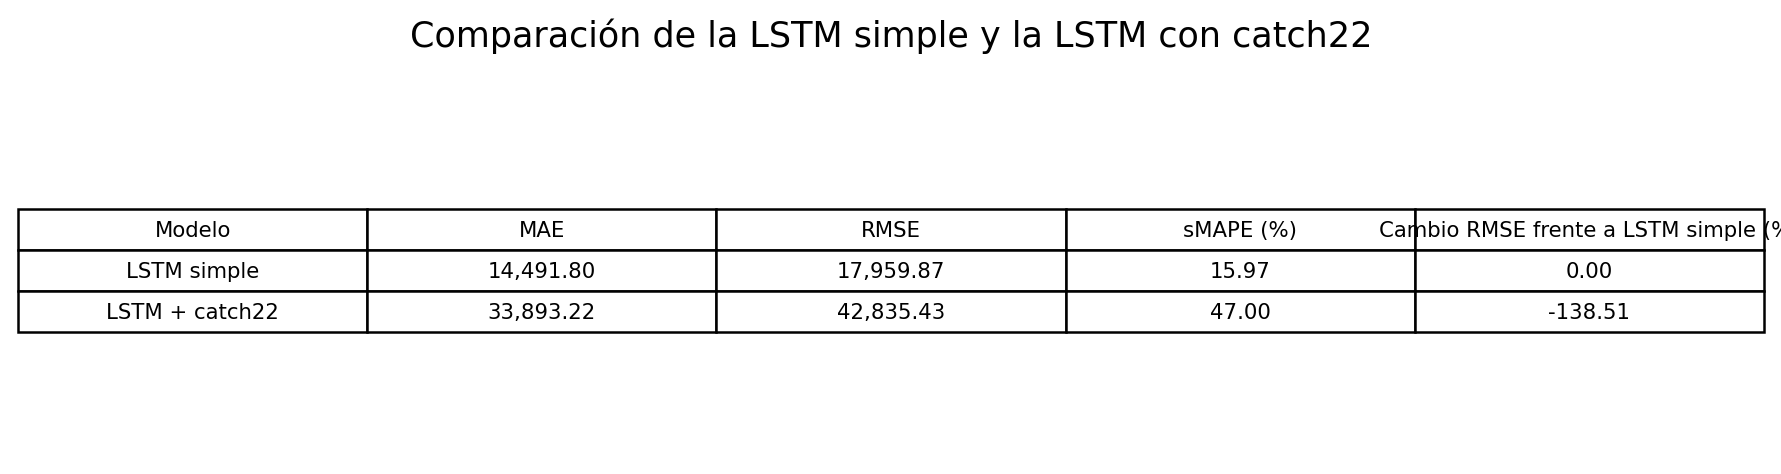

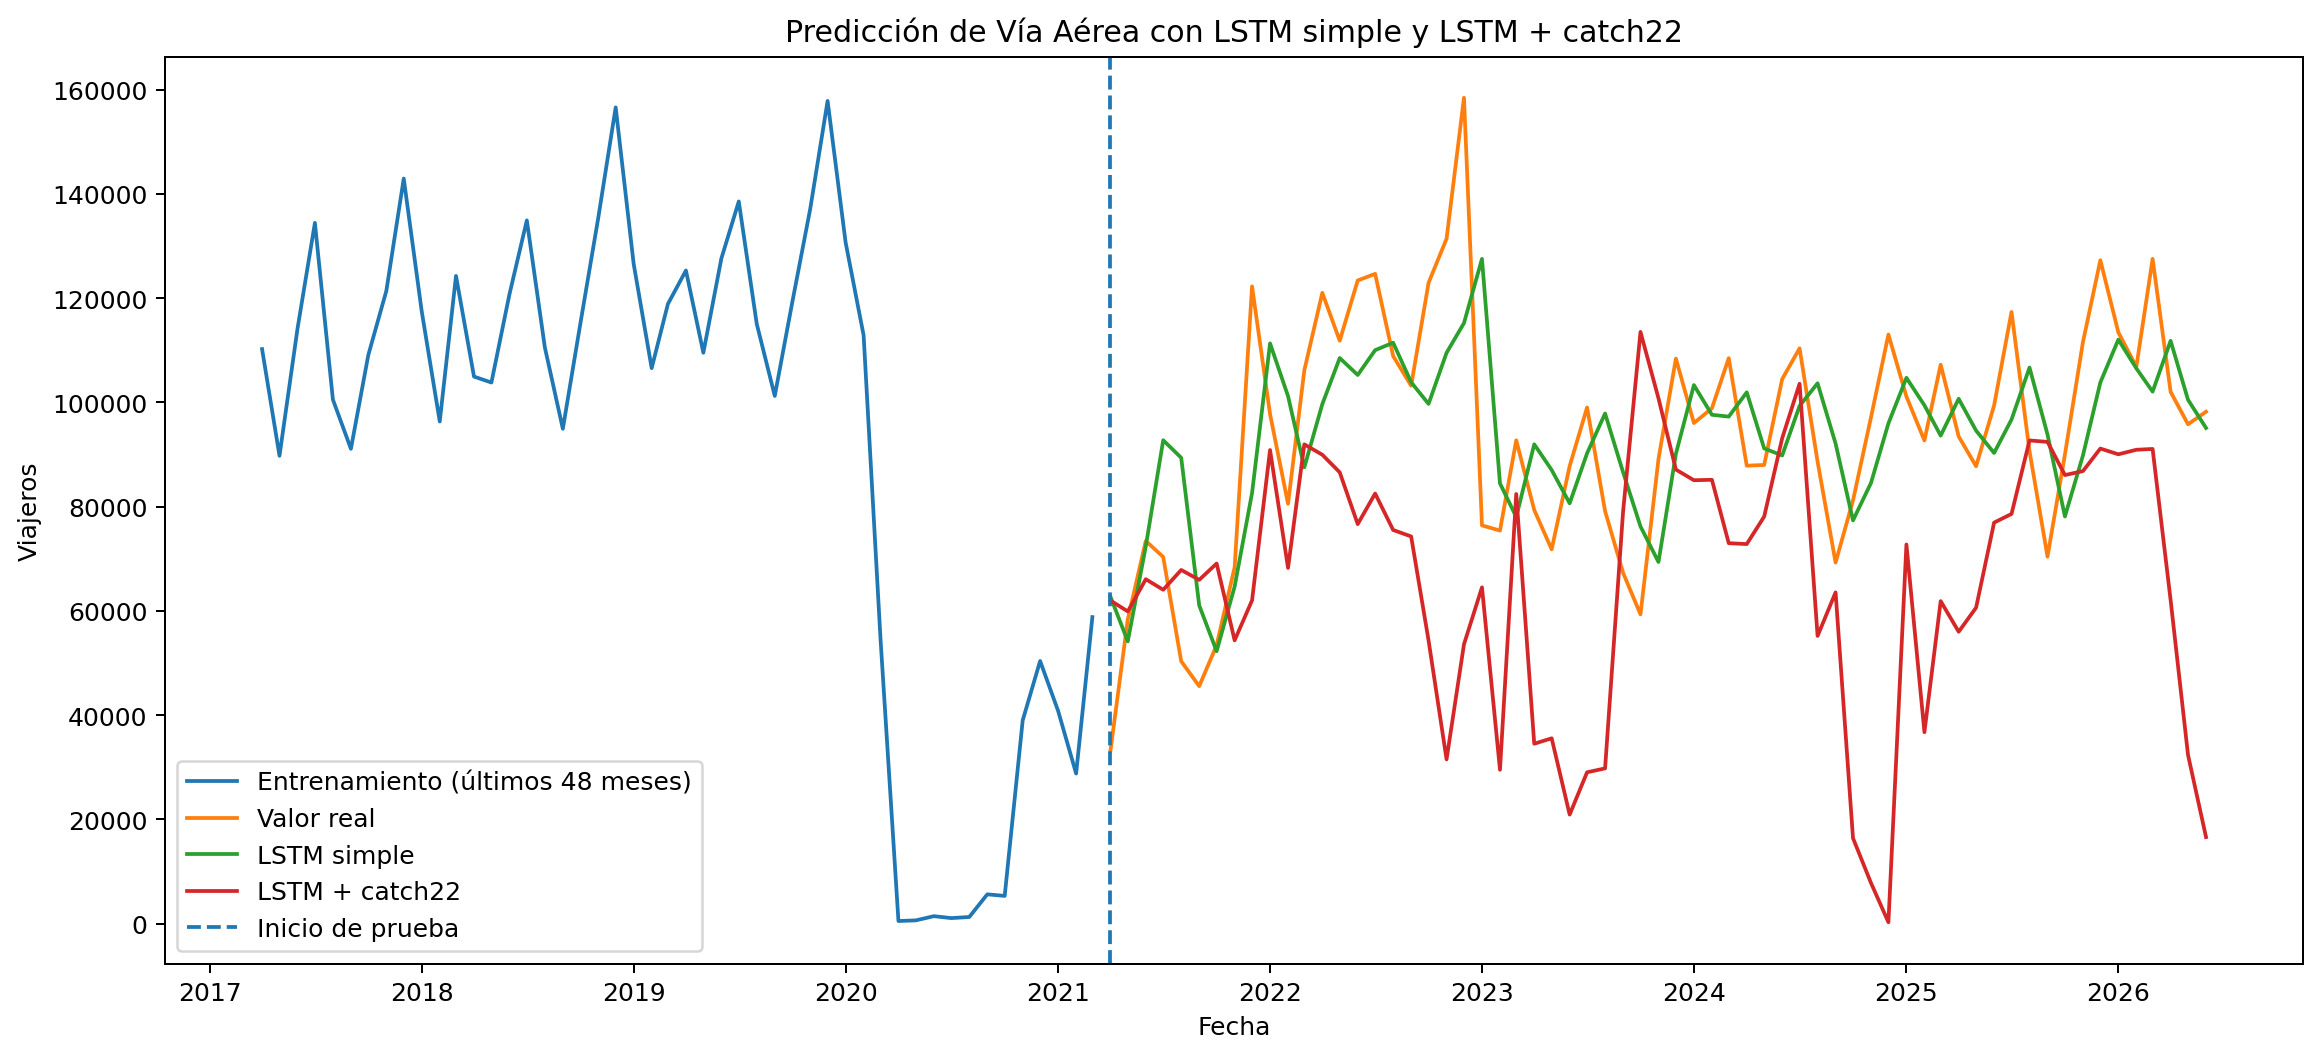

La LSTM con catch22 obtuvo un MAE de 33,893.22, un RMSE de 42,835.43 y un sMAPE de 47.00%. La LSTM simple mantuvo un MAE de 14,491.80, un RMSE de 17,959.87 y un sMAPE de 15.97%.

El modelo híbrido no mejoró la predicción. Su RMSE fue 138.51% mayor que el de la LSTM simple. En la gráfica se observa que siguió de manera general la recuperación, pero produjo sobreestimaciones fuertes y tuvo más dificultad en los cambios mensuales.

Una posible explicación es que solo existen 123 ventanas de entrenamiento después de usar 24 meses como entrada. Agregar 22 características a una muestra pequeña aumenta la complejidad y facilita el sobreajuste. Además, varias características resumen información que la LSTM ya puede aprender directamente de la secuencia, por lo que parte de la entrada es redundante.

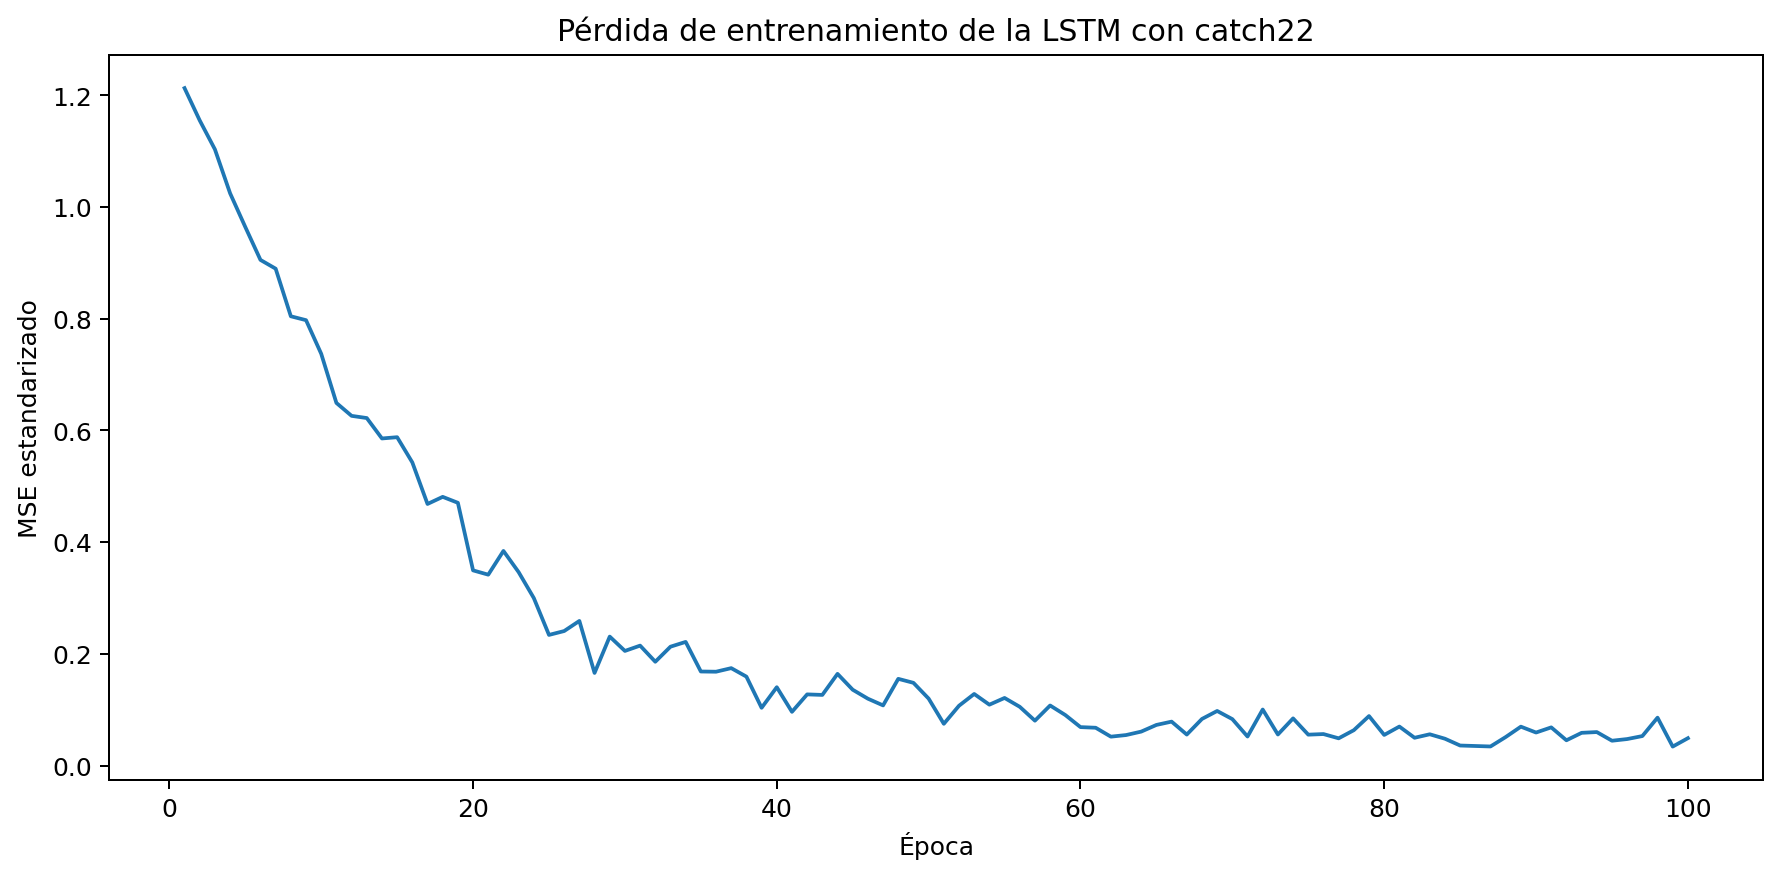

La pérdida de entrenamiento disminuyó de forma estable, pero eso no se tradujo en una mejor generalización. Este resultado refuerza que una pérdida baja durante el entrenamiento no es suficiente para seleccionar un modelo; las métricas de validación y prueba son las que permiten saber si realmente predice mejor.

# Conclusiones 

La LSTM simple fue el mejor modelo para las dos series seleccionadas. Superó al mejor modelo del Laboratorio 1 en Vía Aérea y Vía Terrestre y también superó a la arquitectura LSTM apilada.

El análisis catch22 permitió comparar siete series mediante 22 características estandarizadas. Total y Región América Del Centro fueron las más parecidas, mientras que Vía Marítima fue claramente la más atípica. El PCA explicó 81.9% de la variación con dos componentes y el clustering identificó dos grupos naturales.

Las características que más ayudaron a diferenciar las series se relacionan con autocorrelación, fluctuaciones, eventos extremos, transiciones, entropía y error de pronóstico local. Estos resultados complementan el análisis tradicional de tendencia, estacionalidad, volatilidad y pandemia.

Finalmente, agregar catch22 a una LSTM no garantizó una mejora. En este caso aumentó bastante el error, probablemente porque la cantidad de ventanas era pequeña frente a la complejidad adicional. El mejor resultado general sigue siendo la LSTM simple con una ventana de 24 meses.

## Repositorio

https://github.com/Ninaswiftie09/Data_Science/tree/Laboratorio2